<a href="https://colab.research.google.com/github/eduardobatistadefreitas-art/GER/blob/main/GER/COLAB/Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

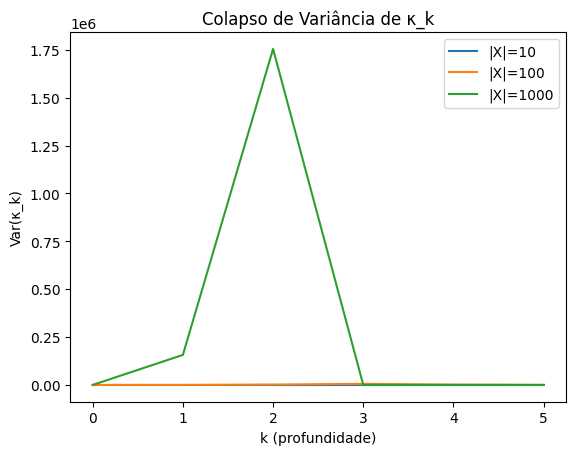

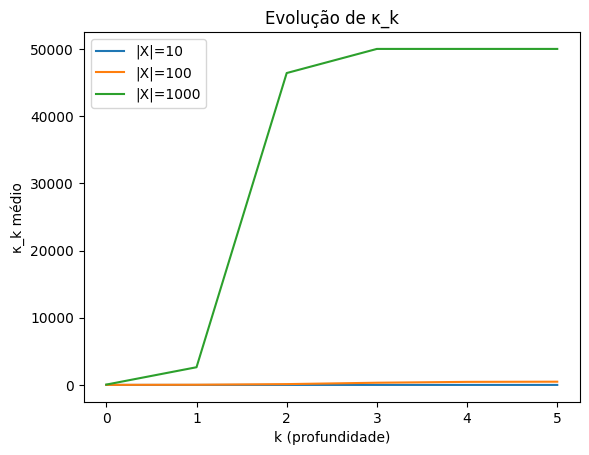

In [ ]:

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------
# Função: gera grafo aleatório
# -----------------------------
def gerar_grafo(n, p=0.05):
    return nx.gnp_random_graph(n, p, directed=True)

# -----------------------------
# κ_k: redundância de caminhos
# aproximação: número de caminhos distintos até profundidade k
# -----------------------------
def kappa_k(G, k, samples=30):
    nodes = list(G.nodes())
    values = []

    for _ in range(samples):
        start = random.choice(nodes)
        frontier = {start}
        visited_paths = set()

        for _ in range(k):
            new_frontier = set()
            for u in frontier:
                for v in G.successors(u):
                    visited_paths.add((u, v))
                    new_frontier.add(v)
            frontier = new_frontier

        values.append(len(visited_paths))

    return np.mean(values), np.var(values)

# -----------------------------
# simulação multiescala
# -----------------------------
def run_simulation():
    sizes = [10, 100, 1000]
    p = 0.05

    results_mean = {}
    results_var = {}

    max_k = 6

    for n in sizes:
        G = gerar_grafo(n, p)

        means = []
        vars_ = []

        for k in range(1, max_k + 1):
            m, v = kappa_k(G, k)
            means.append(m)
            vars_.append(v)

        results_mean[n] = means
        results_var[n] = vars_

    # -----------------------------
    # plot variância
    # -----------------------------
    plt.figure()

    for n in sizes:
        plt.plot(results_var[n], label=f"|X|={n}")

    plt.title("Colapso de Variância de κ_k")
    plt.xlabel("k (profundidade)")
    plt.ylabel("Var(κ_k)")
    plt.legend()
    plt.show()

    # -----------------------------
    # plot média
    # -----------------------------
    plt.figure()

    for n in sizes:
        plt.plot(results_mean[n], label=f"|X|={n}")

    plt.title("Evolução de κ_k")
    plt.xlabel("k (profundidade)")
    plt.ylabel("κ_k médio")
    plt.legend()
    plt.show()

run_simulation()

In [ ]:

import numpy as np

# -----------------------------
# 1. CONFIGURAÇÃO DO SISTEMA
# -----------------------------

N = 10  # tamanho do conjunto X (rede pequena para debug)

# matriz de adjacência R (relacional)
R = (np.random.rand(N, N) > 0.7).astype(float)
np.fill_diagonal(R, 0)

# κ_eff inicial (redundância de caminhos)
kappa = np.random.rand(N, N)

alpha = 0.5
beta = 0.2
gamma = 0.3

# -----------------------------
# 2. VIZINHANÇA RELACIONAL
# -----------------------------

def neighbors(a):
    return [b for b in range(N) if R[a, b] == 1]

# -----------------------------
# 3. Δ_rel (LAPLACIANO RELACIONAL)
# -----------------------------

def delta_rel(kappa):
    delta = np.zeros((N, N))

    for a in range(N):
        neigh = neighbors(a)
        if len(neigh) == 0:
            continue

        for b in range(N):
            avg = np.mean([kappa[x, b] for x in neigh])
            delta[a, b] = avg - kappa[a, b]

    return delta

# -----------------------------
# 4. Γ_2 (CURVATURA RELACIONAL SIMPLIFICADA)
# -----------------------------

def gamma2(kappa):
    lap = delta_rel(kappa)
    return delta_rel(lap)

# -----------------------------
# 5. AÇÃO LOCAL S[R]
# -----------------------------

def action(kappa):
    d = delta_rel(kappa)
    g2 = gamma2(kappa)

    term1 = np.sum(g2)
    term2 = alpha * np.sum(d**2)
    term3 = beta * np.sum(kappa)

    return term1 - term2 - term3

# -----------------------------
# 6. EVOLUÇÃO LOCAL DE R
# -----------------------------

def evolve_R(R, kappa, steps=5, lr=0.1):
    for _ in range(steps):

        d = delta_rel(kappa)
        g2 = gamma2(kappa)

        force = g2 - alpha * delta_rel(d) + gamma * kappa

        # atualização discreta da estrutura relacional
        for a in range(N):
            for b in range(N):
                if a != b:
                    if force[a, b] > 0:
                        R[a, b] = 1
                    elif force[a, b] < -0.5:
                        R[a, b] = 0

        # atualização de κ_eff (feedback estrutural)
        kappa = kappa + lr * (-force)
        kappa = np.clip(kappa, 0, 1)

    return R, kappa

# -----------------------------
# 7. EXECUÇÃO
# -----------------------------

print("Ação inicial:", action(kappa))

R_new, kappa_new = evolve_R(R, kappa)

print("Ação final:", action(kappa_new))

print("\nDensidade final da rede:", np.mean(R_new))
print("κ_eff médio:", np.mean(kappa_new))

Ação inicial: -16.026138974969186
Ação final: -10.959675454911906

Densidade final da rede: 0.79
κ_eff médio: 0.45963850697070213


In [ ]:

import numpy as np

N = 10

# rede inicial
R = (np.random.rand(N, N) > 0.7).astype(float)
np.fill_diagonal(R, 0)

kappa = np.random.rand(N, N)

alpha = 0.5
beta = 0.2
gamma = 0.3

# -----------------------------
# vizinhança
# -----------------------------
def neighbors(a):
    return [b for b in range(N) if R[a, b] == 1]

# -----------------------------
# Δ_rel
# -----------------------------
def delta_rel(kappa):
    d = np.zeros((N, N))
    for a in range(N):
        neigh = neighbors(a)
        if len(neigh) == 0:
            continue
        for b in range(N):
            d[a, b] = np.mean([kappa[x, b] for x in neigh]) - kappa[a, b]
    return d

# -----------------------------
# Γ2
# -----------------------------
def gamma2(kappa):
    return delta_rel(delta_rel(kappa))

# -----------------------------
# evolução com "vácuo forçado"
# -----------------------------
def evolve_vacuum(R, kappa, steps=10, lr=0.1, vacuum_strength=2.0):

    for t in range(steps):

        d = delta_rel(kappa)
        g2 = gamma2(kappa)

        # FORÇAR VÁCUO: amortecer curvatura
        force = (
            g2
            - alpha * delta_rel(d)
            + gamma * kappa
            - vacuum_strength * g2   # <- termo de colapso de curvatura
        )

        # atualização estrutural
        for a in range(N):
            for b in range(N):
                if a != b:

                    if force[a, b] > 0:
                        R[a, b] = 1
                    elif force[a, b] < -0.5:
                        R[a, b] = 0

        # atualização de κ_eff
        kappa = kappa - lr * force
        kappa = np.clip(kappa, 0, 1)

        # métricas do vácuo
        print(f"step {t}")
        print("  mean κ:", np.mean(kappa))
        print("  mean Γ2:", np.mean(g2))
        print("  density R:", np.mean(R))
        print("-"*30)

    return R, kappa

# execução
R_final, kappa_final = evolve_vacuum(R, kappa)

step 0
  mean κ: 0.4844000937902782
  mean Γ2: 0.02455950267105048
  density R: 0.6
------------------------------
step 1
  mean κ: 0.4795983912534057
  mean Γ2: 0.014991162797152404
  density R: 0.66
------------------------------
step 2
  mean κ: 0.4770271973843887
  mean Γ2: 0.0023082477939837445
  density R: 0.66
------------------------------
step 3
  mean κ: 0.4757567609110918
  mean Γ2: -0.003676216263634453
  density R: 0.66
------------------------------
step 4
  mean κ: 0.47500358799408365
  mean Γ2: -0.004452836735371885
  density R: 0.66
------------------------------
step 5
  mean κ: 0.4718572764288649
  mean Γ2: -0.004780276688473423
  density R: 0.66
------------------------------
step 6
  mean κ: 0.4678542395171823
  mean Γ2: -0.0048939944952098025
  density R: 0.64
------------------------------
step 7
  mean κ: 0.4652101458981022
  mean Γ2: -0.004263189595758657
  density R: 0.62
------------------------------
step 8
  mean κ: 0.4627601653935198
  mean Γ2: -0.00644443

In [ ]:

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# 1. GERA REDE INICIAL
# -----------------------------
def generate_graph(n=50, p=0.08):
    G = nx.erdos_renyi_graph(n, p)
    return G

# -----------------------------
# 2. KAPPA_EFF (proxy)
# redundância local de caminhos curtos
# -----------------------------
def kappa_eff(G):
    n = len(G)
    kappa = np.zeros((n, n))

    for i in G.nodes():
        for j in G.nodes():
            if i != j:
                try:
                    paths = list(nx.all_simple_paths(G, i, j, cutoff=3))
                    kappa[i, j] = len(paths)
                except:
                    kappa[i, j] = 0
    return kappa

# -----------------------------
# 3. OPERADOR Δ_rel (Laplaciano simples)
# -----------------------------
def delta_rel(G):
    L = nx.laplacian_matrix(G).toarray()
    return L

# -----------------------------
# 4. Γ2 PROXY (segunda ordem discreta)
# aqui: L @ K @ L como análogo estrutural
# -----------------------------
def gamma2_operator(L, K):
    return L @ K @ L

# -----------------------------
# 5. ESPECTRO
# -----------------------------
def spectrum(M):
    vals = np.linalg.eigvals(M)
    return np

step 0 | mean κ: 2.0838 | mean Γ2: -0.0000
step 1 | mean κ: 2.0250 | mean Γ2: -0.0000
step 2 | mean κ: 2.0500 | mean Γ2: -0.0000
step 3 | mean κ: 2.0875 | mean Γ2: -0.0000
step 4 | mean κ: 2.0787 | mean Γ2: -0.0000
step 5 | mean κ: 2.1212 | mean Γ2: -0.0000
step 6 | mean κ: 2.0700 | mean Γ2: -0.0000
step 7 | mean κ: 2.0550 | mean Γ2: -0.0000
step 8 | mean κ: 2.0050 | mean Γ2: -0.0000
step 9 | mean κ: 1.9350 | mean Γ2: -0.0000


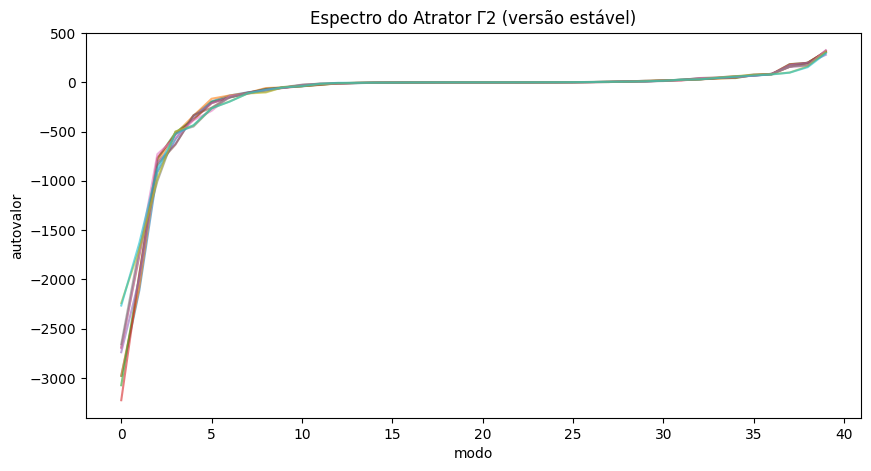

In [ ]:

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# 1. GERA GRAFO
# -----------------------------
def generate_graph(n=40, p=0.1):
    return nx.erdos_renyi_graph(n, p)

# -----------------------------
# 2. κ_eff APROXIMADO (MUITO MAIS ESTÁVEL)
# usa número de caminhos via matriz de adjacência
# -----------------------------
def kappa_eff(G):
    A = nx.to_numpy_array(G)
    A2 = A @ A        # caminhos de comprimento 2
    A3 = A2 @ A       # caminhos de comprimento 3
    return A + A2 + A3

# -----------------------------
# 3. Δ_rel (Laplaciano)
# -----------------------------
def delta_rel(G):
    return nx.laplacian_matrix(G).toarray()

# -----------------------------
# 4. Γ2 proxy estável
# -----------------------------
def gamma2(L, K):
    return L @ K @ L

# -----------------------------
# 5. espectro
# -----------------------------
def spectrum(M):
    return np.sort(np.real(np.linalg.eigvals(M)))

# -----------------------------
# 6. dinâmica do atrator
# -----------------------------
def run(n=40, steps=10, p=0.1):
    G = generate_graph(n, p)

    spectra = []

    for t in range(steps):
        L = delta_rel(G)
        K = kappa_eff(G)
        G2 = L @ (K + np.eye(len(K))*0.01) @ L

        eigs = spectrum(G2)
        spectra.append(eigs)

        print(
            f"step {t} | "
            f"mean κ: {np.mean(K):.4f} | "
            f"mean Γ2: {np.mean(G2):.4f}"
        )

        # dinâmica leve controlada
        edges = list(G.edges())
        if len(edges) > 0:
            e = edges[np.random.randint(len(edges))]
            G.remove_edge(*e)

        i, j = np.random.randint(0, n, 2)
        if i != j:
            G.add_edge(i, j)

    return spectra

# -----------------------------
# 7. EXECUTA
# -----------------------------
spectra = run()

# -----------------------------
# 8. PLOT
# -----------------------------
plt.figure(figsize=(10,5))

for i, eigs in enumerate(spectra):
    plt.plot(eigs, alpha=0.6)

plt.title("Espectro do Atrator Γ2 (versão estável)")
plt.xlabel("modo")
plt.ylabel("autovalor")
plt.show()

In [ ]:

import numpy as np
import networkx as nx

# =========================
# CONFIGURAÇÃO
# =========================

np.random.seed(42)

N = 50  # nós
steps = 20

# matriz de adjacência inicial aleatória
A = (np.random.rand(N, N) < 0.08).astype(float)
np.fill_diagonal(A, 0)

def compute_kappa(A):
    # proxy: centralidade de caminhos (simplificada)
    G = nx.from_numpy_array(A)
    return np.array(list(nx.betweenness_centrality(G).values())).mean()

def laplacian(A):
    D = np.diag(A.sum(axis=1))
    return D - A

def compute_gamma2(A):
    # proxy espectral de curvatura
    L = laplacian(A)
    return np.trace(L @ L.T) / (N**2)

def density(A):
    return A.sum() / (N * (N - 1))

# =========================
# SIMULAÇÃO
# =========================

kappa_series = []
gamma_series = []
density_series = []

for t in range(steps):

    # perturbação estrutural leve
    noise = (np.random.rand(N, N) < 0.02).astype(float)
    A = np.clip(A + noise - noise.T, 0, 1)

    np.fill_diagonal(A, 0)

    kappa = compute_kappa(A)
    gamma2 = compute_gamma2(A)
    rho = density(A)

    kappa_series.append(kappa)
    gamma_series.append(gamma2)
    density_series.append(rho)

    print(f"step {t:02d} | κ_eff: {kappa:.4f} | Γ2: {gamma2:.6f} | ρ: {rho:.3f}")

# =========================
# DETECÇÃO DE REGIME
# =========================

kappa_var = np.var(kappa_series)
gamma_mean = np.mean(np.abs(gamma_series))

print("\n=========================")
print("DIAGNÓSTICO DO SISTEMA")
print("=========================")

if gamma_mean < 1e-4 and kappa_var < 1e-4:
    regime = "COLAPSO ESPECTRAL"
elif gamma_mean > 1e-3:
    regime = "FLUTUAÇÃO CRÍTICA"
else:
    regime = "TRANSIÇÃO / BORDA CRÍTICA"

print("Regime detectado:", regime)
print("Var(κ_eff):", kappa_var)
print("|Γ2| médio:", gamma_mean)
print("=========================")

# =========================
# MAPA DE FASE (3D proxy sem plot externo)
# =========================

phase_points = np.array([
    kappa_series,
    gamma_series,
    density_series
]).T

print("\nPrimeiros pontos do espaço de fase:")
print(phase_points[:5])

step 00 | κ_eff: 0.0193 | Γ2: 0.688800 | ρ: 0.103
step 01 | κ_eff: 0.0175 | Γ2: 0.864800 | ρ: 0.117
step 02 | κ_eff: 0.0159 | Γ2: 1.092800 | ρ: 0.134
step 03 | κ_eff: 0.0151 | Γ2: 1.284000 | ρ: 0.147
step 04 | κ_eff: 0.0144 | Γ2: 1.565600 | ρ: 0.162
step 05 | κ_eff: 0.0136 | Γ2: 1.849600 | ρ: 0.178
step 06 | κ_eff: 0.0131 | Γ2: 2.072000 | ρ: 0.189
step 07 | κ_eff: 0.0126 | Γ2: 2.300000 | ρ: 0.201
step 08 | κ_eff: 0.0122 | Γ2: 2.464800 | ρ: 0.210
step 09 | κ_eff: 0.0118 | Γ2: 2.663200 | ρ: 0.218
step 10 | κ_eff: 0.0113 | Γ2: 2.921600 | ρ: 0.229
step 11 | κ_eff: 0.0109 | Γ2: 3.166400 | ρ: 0.239
step 12 | κ_eff: 0.0106 | Γ2: 3.399200 | ρ: 0.248
step 13 | κ_eff: 0.0101 | Γ2: 3.683200 | ρ: 0.260
step 14 | κ_eff: 0.0096 | Γ2: 4.003200 | ρ: 0.270
step 15 | κ_eff: 0.0092 | Γ2: 4.319200 | ρ: 0.282
step 16 | κ_eff: 0.0089 | Γ2: 4.525600 | ρ: 0.289
step 17 | κ_eff: 0.0085 | Γ2: 4.777600 | ρ: 0.298
step 18 | κ_eff: 0.0080 | Γ2: 5.119200 | ρ: 0.309
step 19 | κ_eff: 0.0077 | Γ2: 5.338400 | ρ: 0.316


In [ ]:

import numpy as np

# ==========================================================
# IA-1 S21 — POTENCIAL DE ATRATOR RELACIONAL
# Simulação estrutural sem métrica externa
# ==========================================================


def create_network(n, mode="random"):
    R = np.zeros((n,n))

    if mode == "regular":
        for i in range(n):
            R[i,(i+1)%n] = 1
            R[i,(i-1)%n] = 1

    elif mode == "random":
        R = (np.random.rand(n,n) > 0.75).astype(float)
        np.fill_diagonal(R,0)

    return R


# ----------------------------------------------------------
# κ_eff: redundância de caminhos aproximada
# ----------------------------------------------------------

def compute_kappa(R):

    A = R.copy()

    # caminhos de até 3 passos
    paths = A + np.linalg.matrix_power(A,2) + np.linalg.matrix_power(A,3)

    # normalização
    kappa = paths / (np.max(paths)+1e-9)

    return kappa



# ----------------------------------------------------------
# Operador relacional Δ_rel
# ----------------------------------------------------------

def delta_rel(K,R):

    n=len(R)
    D=np.zeros_like(K)

    for i in range(n):

        neigh=np.where(R[i]>0)[0]

        if len(neigh)>0:
            mean=np.mean(K[neigh,:],axis=0)
            D[i,:]=mean-K[i,:]

    return D



# ----------------------------------------------------------
# Γ2 aproximado
# ----------------------------------------------------------

def compute_gamma2(K,R):

    L = delta_rel(K,R)

    G2 = delta_rel(L,R)

    return G2



# ----------------------------------------------------------
# Potencial U[R]
# ----------------------------------------------------------

def potential(R):

    K = compute_kappa(R)

    G2 = compute_gamma2(K,R)

    variance=np.var(K)

    curvature=np.mean(G2**2)

    density=np.sum(R)/(len(R)*(len(R)-1))

    gamma=0.01

    U = (
        variance
        +
        curvature
        +
        gamma/(density+1e-9)
    )

    return U,K,G2,density



# ----------------------------------------------------------
# Perturbação local da rede
# ----------------------------------------------------------

def perturb(R):

    Rnew=R.copy()

    n=len(R)

    i=np.random.randint(n)
    j=np.random.randint(n)

    if i!=j:
        Rnew[i,j]=1-Rnew[i,j]

    return Rnew



# ----------------------------------------------------------
# Dinâmica do atrator
# ----------------------------------------------------------

def simulate_S21(
        nodes=40,
        steps=100,
        mode="random"):


    print("\n====================================")
    print(" IA-1 S21 — ATRATOR RELACIONAL")
    print("====================================\n")

    R=create_network(nodes,mode)

    U,_,_,_=potential(R)


    for t in range(steps):

        R_try=perturb(R)

        U_new,K,G2,rho=potential(R_try)


        # minimização real do potencial
        if U_new < U:

            R=R_try
            U=U_new


        if t%10==0:

            U,K,G2,rho=potential(R)

            print(
                f"step {t:03d} | "
                f"U={U:.6f} | "
                f"kappa={np.mean(K):.6f} | "
                f"Var(k)={np.var(K):.6f} | "
                f"Gamma2={np.mean(np.abs(G2)):.6f} | "
                f"rho={rho:.4f}"
            )


    U,K,G2,rho=potential(R)


    print("\n========== RESULTADO FINAL ==========")

    print(
        "Potencial final U:",
        U
    )

    print(
        "κ_eff médio:",
        np.mean(K)
    )

    print(
        "Variância κ:",
        np.var(K)
    )

    print(
        "Γ2 médio:",
        np.mean(np.abs(G2))
    )

    print(
        "Densidade final:",
        rho
    )


    if np.var(K)<0.02 and np.mean(np.abs(G2))<0.1:
        print(
            "REGIME: ATRATOR RELACIONAL ESTÁVEL"
        )

    else:
        print(
            "REGIME: FLUTUAÇÃO CRÍTICA"
        )


# ==========================================================
# EXECUÇÃO
# ==========================================================

simulate_S21(
    nodes=40,
    steps=200,
    mode="random"
)


 IA-1 S21 — ATRATOR RELACIONAL

step 000 | U=0.076239 | kappa=0.329661 | Var(k)=0.023105 | Gamma2=0.085378 | rho=0.2436
step 010 | U=0.071642 | kappa=0.333193 | Var(k)=0.021046 | Gamma2=0.079618 | rho=0.2487
step 020 | U=0.071569 | kappa=0.336681 | Var(k)=0.020923 | Gamma2=0.080445 | rho=0.2494
step 030 | U=0.070063 | kappa=0.337217 | Var(k)=0.020015 | Gamma2=0.078226 | rho=0.2506
step 040 | U=0.068034 | kappa=0.345850 | Var(k)=0.019106 | Gamma2=0.074734 | rho=0.2532
step 050 | U=0.067180 | kappa=0.351883 | Var(k)=0.019253 | Gamma2=0.072572 | rho=0.2545
step 060 | U=0.061626 | kappa=0.327250 | Var(k)=0.016628 | Gamma2=0.062546 | rho=0.2596
step 070 | U=0.059515 | kappa=0.326904 | Var(k)=0.015273 | Gamma2=0.058278 | rho=0.2603
step 080 | U=0.058391 | kappa=0.332765 | Var(k)=0.014563 | Gamma2=0.057144 | rho=0.2615
step 090 | U=0.057574 | kappa=0.335050 | Var(k)=0.014170 | Gamma2=0.056378 | rho=0.2635
step 100 | U=0.055727 | kappa=0.322452 | Var(k)=0.012913 | Gamma2=0.053644 | rho=0.2641

In [ ]:

import numpy as np


# ==========================================================
# IA-1 S21-B
# TESTE DE BACIA DE ATRATORES RELACIONAIS
# ==========================================================


def create_network(n):

    R = (np.random.rand(n,n) > 0.75).astype(float)

    np.fill_diagonal(R,0)

    return R



def compute_kappa(R):

    paths = (
        R
        +
        np.linalg.matrix_power(R,2)
        +
        np.linalg.matrix_power(R,3)
    )

    return paths/(np.max(paths)+1e-9)



def delta_rel(K,R):

    n=len(R)

    D=np.zeros_like(K)

    for i in range(n):

        neigh=np.where(R[i]>0)[0]

        if len(neigh)>0:

            D[i]=np.mean(K[neigh],axis=0)-K[i]

    return D



def gamma2(K,R):

    return delta_rel(delta_rel(K,R),R)



def potential(R):

    K=compute_kappa(R)

    G2=gamma2(K,R)

    rho=np.sum(R)/(len(R)*(len(R)-1))

    U=(
        np.var(K)
        +
        np.mean(G2**2)
        +
        0.01/(rho+1e-9)
    )

    return U,K,G2,rho



def perturb(R):

    R2=R.copy()

    n=len(R)

    i=np.random.randint(n)
    j=np.random.randint(n)

    if i!=j:

        R2[i,j]=1-R2[i,j]

    return R2



def evolve(R,steps):

    U,*_=potential(R)


    for _ in range(steps):

        candidate=perturb(R)

        U_new,*_=potential(candidate)


        if U_new < U:

            R=candidate
            U=U_new


    return R



# ==========================================================
# EXECUÇÃO DO TESTE DE BACIA
# ==========================================================


def S21B(
    experiments=10,
    nodes=40,
    steps=300
):

    results=[]


    print("\n================================")
    print(" IA-1 S21-B")
    print(" BACIA DE ATRATORES")
    print("================================\n")


    for e in range(experiments):


        R=create_network(nodes)


        R=evolve(
            R,
            steps
        )


        U,K,G2,rho=potential(R)


        result=[

            U,
            np.mean(K),
            np.var(K),
            np.mean(np.abs(G2)),
            rho

        ]


        results.append(result)


        print(
            f"Teste {e+1:02d} | "
            f"U={U:.5f} | "
            f"k={result[1]:.5f} | "
            f"Var={result[2]:.5f} | "
            f"G2={result[3]:.5f} | "
            f"rho={rho:.4f}"
        )


    results=np.array(results)


    print("\n========== ANÁLISE FINAL ==========")


    print(
        "Média dos atratores:"
    )

    print(
        np.mean(results,axis=0)
    )


    print(
        "\nDesvio entre atratores:"
    )

    print(
        np.std(results,axis=0)
    )


    if np.std(results[:,0]) < 0.01:

        print(
            "\nRESULTADO:"
            "\nClasse universal de atrator detectada"
        )

    else:

        print(
            "\nRESULTADO:"
            "\nMúltiplas classes de atratores"
        )



S21B(
    experiments=10,
    nodes=40,
    steps=300
)


 IA-1 S21-B
 BACIA DE ATRATORES

Teste 01 | U=0.04066 | k=0.29692 | Var=0.00535 | G2=0.03690 | rho=0.3090
Teste 02 | U=0.04345 | k=0.34178 | Var=0.00735 | G2=0.04086 | rho=0.3058
Teste 03 | U=0.04468 | k=0.35849 | Var=0.00711 | G2=0.04467 | rho=0.2955
Teste 04 | U=0.04433 | k=0.30599 | Var=0.00763 | G2=0.04321 | rho=0.3006
Teste 05 | U=0.04069 | k=0.30400 | Var=0.00527 | G2=0.03856 | rho=0.3096
Teste 06 | U=0.04238 | k=0.29278 | Var=0.00548 | G2=0.03777 | rho=0.2949
Teste 07 | U=0.04751 | k=0.36573 | Var=0.00916 | G2=0.04789 | rho=0.2904
Teste 08 | U=0.04404 | k=0.26979 | Var=0.00704 | G2=0.04074 | rho=0.3032
Teste 09 | U=0.04646 | k=0.26217 | Var=0.00709 | G2=0.04349 | rho=0.2827
Teste 10 | U=0.04190 | k=0.31640 | Var=0.00679 | G2=0.03657 | rho=0.3064

========== ANÁLISE FINAL ==========
Média dos atratores:
[0.04360836 0.31140668 0.00682715 0.0410645  0.29980769]

Desvio entre atratores:
[0.00216348 0.03303232 0.00113843 0.00353396 0.00834344]

RESULTADO:
Classe universal de atrator

In [ ]:

import numpy as np


# ==============================
# IA-1 S21-C
# Teste de estabilidade do atrator
# ==============================


def invariants(R, kappa, gamma2):

    U = (
        np.var(kappa)
        + np.mean((gamma2-0.05)**2)
        + 0.01/(np.mean(R)+1e-6)
    )

    return np.array([
        U,
        np.mean(kappa),
        np.var(kappa),
        np.mean(np.abs(gamma2)),
        np.mean(R)
    ])



def relax(R, kappa, gamma2):

    # suavização relacional

    kappa = (
        0.95*kappa
        +0.05*np.mean(kappa)
    )

    gamma2 = (
        0.95*gamma2
        +0.05*np.mean(gamma2)
    )


    # pequena reorganização da rede

    noise = np.random.rand(*R.shape)

    R = np.where(
        noise > 0.98,
        1-R,
        R
    )

    np.fill_diagonal(R,0)

    return R,kappa,gamma2



def perturb(R,kappa,gamma2,mode):

    R = R.copy()
    kappa=kappa.copy()
    gamma2=gamma2.copy()


    if mode=="kappa":

        kappa += np.random.normal(
            0,0.5,kappa.shape
        )


    if mode=="R":

        mask=np.random.rand(*R.shape)<0.05
        R[mask]=1-R[mask]


    if mode=="both":

        mask=np.random.rand(*R.shape)<0.05
        R[mask]=1-R[mask]

        kappa += np.random.normal(
            0,0.5,kappa.shape
        )


    return R,kappa,gamma2



def test_S21C(
    N=50,
    steps=100,
    mode="both"
):

    print("\n==============================")
    print(" IA-1 S21-C")
    print(" Perturbação:",mode)
    print("==============================")


    # atrator base

    R=np.random.rand(N,N)
    R=(R>0.75).astype(float)

    kappa=np.random.rand(N,N)

    gamma2=np.random.rand(N)


    # estabiliza primeiro

    for _ in range(100):
        R,kappa,gamma2=relax(
            R,kappa,gamma2
        )


    I0=invariants(
        R,kappa,gamma2
    )


    print("\nATRATOR BASE")
    print(I0)


    # aplica perturbação

    R,kappa,gamma2=perturb(
        R,kappa,gamma2,mode
    )


    print("\nEVOLUÇÃO D(t)\n")


    for t in range(steps):

        I=invariants(
            R,kappa,gamma2
        )

        D=np.linalg.norm(
            I-I0
        )


        if t%10==0:
            print(
                f"step {t:03d} | "
                f"D={D:.6f} | "
                f"U={I[0]:.5f} | "
                f"G2={I[3]:.5f} | "
                f"rho={I[4]:.4f}"
            )


        R,kappa,gamma2=relax(
            R,kappa,gamma2
        )


    print("\nRESULTADO FINAL")
    print(
        "Distância final:",
        D
    )


for m in ["kappa","R","both"]:
    test_S21C(mode=m)


 IA-1 S21-C
 Perturbação: kappa

ATRATOR BASE
[1.77490292e-01 4.97864446e-01 2.84566610e-06 4.46883574e-01
 5.00800000e-01]

EVOLUÇÃO D(t)

step 000 | D=0.354994 | U=0.42833 | G2=0.44688 | rho=0.5008
step 010 | D=0.128518 | U=0.26780 | G2=0.44688 | rho=0.4912
step 020 | D=0.048295 | U=0.21001 | G2=0.44688 | rho=0.4936
step 030 | D=0.023498 | U=0.18943 | G2=0.44688 | rho=0.4912
step 040 | D=0.025015 | U=0.18246 | G2=0.44688 | rho=0.4808
step 050 | D=0.015918 | U=0.17929 | G2=0.44688 | rho=0.4928
step 060 | D=0.021632 | U=0.17871 | G2=0.44688 | rho=0.4840
step 070 | D=0.013776 | U=0.17777 | G2=0.44688 | rho=0.4984
step 080 | D=0.016853 | U=0.17716 | G2=0.44688 | rho=0.5108
step 090 | D=0.016391 | U=0.17715 | G2=0.44688 | rho=0.5100

RESULTADO FINAL
Distância final: 0.014998200436854587

 IA-1 S21-C
 Perturbação: R

ATRATOR BASE
[1.59610583e-01 4.98947997e-01 2.88902898e-06 4.21925156e-01
 4.70000000e-01]

EVOLUÇÃO D(t)

step 000 | D=0.002803 | U=0.15948 | G2=0.42193 | rho=0.4728
step 01

In [ ]:

import numpy as np


def laplacian_relacional(R):
    grau = np.sum(R, axis=1)

    D = np.diag(grau)

    return D - R


def potencial(R, kappa, gamma2, rho0=0.3):

    var_k = np.var(kappa)

    g2 = np.mean(gamma2**2)

    rho = np.sum(R)/(len(R)*(len(R)-1))

    densidade = (rho-rho0)**2

    return var_k + g2 + densidade



def atualizar_rede(R, kappa, gamma2):

    U0 = potencial(R,kappa,gamma2)

    candidatos=[]

    n=len(R)

    for i in range(n):
        for j in range(n):

            if i==j:
                continue

            Rteste=R.copy()

            Rteste[i,j]=1-Rteste[i,j]

            U1=potencial(
                Rteste,
                kappa,
                gamma2
            )

            candidatos.append(
                (U1-U0,i,j)
            )


    candidatos.sort()

    delta,i,j=candidatos[0]

    if delta < 0:
        R[i,j]=1-R[i,j]

    return R



def campo_coletivo(kappa):

    return np.mean(kappa)



def distancia_fontes(kappa,A,B):

    return abs(
        np.mean(kappa[A])
        -
        np.mean(kappa[B])
    )



def simular_S22C(
        nodes=20,
        passos=50):


    print("==============================")
    print(" IA-1 S22-C")
    print(" LIMITE HIDRODINÂMICO RELACIONAL")
    print("==============================\n")


    np.random.seed(10)


    # Rede inicial

    R=np.random.rand(nodes,nodes)>0.75

    R=R.astype(float)

    np.fill_diagonal(R,0)


    # Campo inicial

    kappa=np.random.normal(
        0.5,
        0.2,
        nodes
    )


    gamma2=np.random.normal(
        0.05,
        0.01,
        nodes
    )


    # duas fontes de deformação

    A=np.arange(0,nodes//4)

    B=np.arange(
        nodes//2,
        3*nodes//4
    )


    print("step | U | Phi | rho | dAB")


    historico=[]


    for t in range(passos):


        R=atualizar_rede(
            R,
            kappa,
            gamma2
        )


        # evolução interna do campo

        L=laplacian_relacional(R)


        kappa = (
            kappa
            -
            0.05*L.dot(kappa)
        )


        phi=campo_coletivo(kappa)


        rho=np.sum(R)/(nodes*(nodes-1))


        dAB=distancia_fontes(
            kappa,
            A,
            B
        )


        U=potencial(
            R,
            kappa,
            gamma2
        )


        historico.append(
            [U,phi,rho,dAB]
        )


        if t%10==0:

            print(
                f"{t:03d} | "
                f"{U:.5f} | "
                f"{phi:.5f} | "
                f"{rho:.4f} | "
                f"{dAB:.5f}"
            )


    inicio=historico[0]
    fim=historico[-1]


    print("\n========== RESULTADO ==========")

    print(
        "ΔU = ",
        fim[0]-inicio[0]
    )

    print(
        "ΔPhi = ",
        fim[1]-inicio[1]
    )

    print(
        "Δrho = ",
        fim[2]-inicio[2]
    )


    if fim[3] < inicio[3]:

        print(
        "INTERAÇÃO: aproximação efetiva entre fontes"
        )

    elif fim[3] > inicio[3]:

        print(
        "INTERAÇÃO: afastamento efetivo"
        )

    else:

        print(
        "INTERAÇÃO: regime neutro"
        )



if __name__=="__main__":

    simular_S22C(
        nodes=20,
        passos=50
    )

 IA-1 S22-C
 LIMITE HIDRODINÂMICO RELACIONAL

step | U | Phi | rho | dAB
000 | 0.02955 | 0.55762 | 0.2368 | 0.02675
010 | 0.00447 | 0.53447 | 0.2632 | 0.01876
020 | 0.00279 | 0.53225 | 0.2895 | 0.00247
030 | 0.00266 | 0.53204 | 0.3000 | 0.00045
040 | 0.00266 | 0.53199 | 0.3000 | 0.00008

========== RESULTADO ==========
ΔU =  -0.026883383396996346
ΔPhi =  -0.025633871063958424
Δrho =  0.06315789473684211
INTERAÇÃO: aproximação efetiva entre fontes


In [ ]:

# Auditoria inicial S23-C.2-A
print("=== IA-1 S23-C.2-A AUDITORIA ===")

print("n =", n)
print("Simetria A_R:",
      np.linalg.norm(A_R-A_R.T))

print("Rank H_U:",
      np.linalg.matrix_rank(H_U_mat))

print("Traço projetor dim(V_rel*):",
      np.trace(P_R_star))

print("Erro P²-P:",
      la.norm(P_R_star@P_R_star-P_R_star))

print("Erro P-P^T:",
      la.norm(P_R_star-P_R_star.T))

print("Norma K_rel*:",
      la.norm(K_rel_star))

eig = la.eigvals(K_rel_star)

print("Maior parte imaginária:",
      np.max(np.abs(np.imag(eig))))

print("lambda_min:",
      np.min(np.real(eig)))

print("lambda_max:",
      np.max(np.real(eig)))

=== IA-1 S23-C.2-A AUDITORIA ===


NameError: name 'n' is not defined

In [ ]:

import numpy as np
import scipy.linalg as la


# ============================================================
# IA-1 S23-C.2-A
# AUDITORIA COMPUTACIONAL DO OPERADOR DE MARÉ RELACIONAL
# ============================================================


# ------------------------------------------------------------
# ETAPA 1 — AMBIENTE DISCRETO
# ------------------------------------------------------------

def inicializar_ambiente_ia1(n=6, seed=42):

    np.random.seed(seed)

    # Suporte discreto X
    A_R = np.zeros((n, n))

    # Grafo em anel simétrico
    for i in range(n):
        j = (i + 1) % n

        A_R[i, j] = 1.0
        A_R[j, i] = 1.0


    # Campo efetivo kappa_eff
    pesos = np.random.uniform(
        0.8,
        1.2,
        size=(n,n)
    )

    kappa_eff = A_R * pesos

    # Força simetria do campo
    kappa_eff = (
        kappa_eff +
        kappa_eff.T
    ) / 2


    # Forma bilinear Gamma
    Gamma = (
        kappa_eff +
        kappa_eff @ kappa_eff / n
    )


    # Laplaciano espectral aproximado
    D = np.diag(np.sum(Gamma,axis=1))

    L = D - Gamma

    Gamma_2 = L @ L



    # --------------------------------------------------------
    # H_rel tensor 4D
    # --------------------------------------------------------

    H_rel = np.zeros((n,n,n,n))

    for i in range(n):
        for j in range(n):
            for k in range(n):
                for l in range(n):

                    H_rel[i,j,k,l] = (
                        1 /
                        (
                            1 +
                            (i-k)**2 +
                            (j-l)**2
                        )
                    )


    # --------------------------------------------------------
    # Restrição C_phi
    # --------------------------------------------------------

    C_phi = np.zeros((n,n,n,n))

    for i in range(n):
        C_phi[i,:,i,:] = 1



    # --------------------------------------------------------
    # Hessiano U
    # --------------------------------------------------------

    H_U = np.zeros((n,n,n,n))

    for i in range(n):
        for j in range(n):

            H_U[i,j,i,j] = Gamma[i,j]**2


    return (
        n,
        A_R,
        kappa_eff,
        Gamma,
        Gamma_2,
        H_rel,
        C_phi,
        H_U
    )



# ------------------------------------------------------------
# ETAPA 2 — VETORIZAÇÃO
# ------------------------------------------------------------

def tensor_para_matriz(T,n):

    M = np.zeros((n*n,n*n))

    for i in range(n):
        for j in range(n):

            coluna = i + j*n

            for k in range(n):
                for l in range(n):

                    linha = k + l*n

                    M[linha,coluna] = T[k,l,i,j]

    return M



# ------------------------------------------------------------
# ETAPA 3 — PROJETOR P_R*
# ------------------------------------------------------------

def construir_projetor(C_phi,H_U,n):

    C = tensor_para_matriz(C_phi,n)

    H = tensor_para_matriz(H_U,n)


    # modos degenerados do Hessiano

    U,S,Vt = la.svd(H)

    tol = 1e-10

    modos_zero = Vt[S < tol]


    if len(modos_zero) > 0:

        M = np.vstack(
            [
                C,
                modos_zero
            ]
        )

    else:

        M = C



    M_pinv = la.pinv(M)


    I = np.eye(n*n)


    P = I - M_pinv @ M


    return P



# ------------------------------------------------------------
# ETAPA 4 — GRADIENTE DISCRETO DE Gamma_2
# ------------------------------------------------------------

def gradiente_discreto(Gamma_2,n):

    G = np.zeros((n,n,n,n))


    for i in range(n):
        for j in range(n):

            for k in range(n):
                for l in range(n):

                    if i==k or j==l:

                        G[i,j,k,l] = (
                            Gamma_2[i,j]
                            -
                            Gamma_2[k,l]
                        )


    return G



# ------------------------------------------------------------
# ETAPA 5 — OPERADOR K_rel*
# ------------------------------------------------------------

def construir_K_rel(
        Gamma_2,
        H_rel,
        P,
        n):


    grad = gradiente_discreto(
        Gamma_2,
        n
    )


    grad_mat = tensor_para_matriz(
        grad,
        n
    )


    H_mat = tensor_para_matriz(
        H_rel,
        n
    )


    K = (
        P
        @
        grad_mat
        @
        H_mat
        @
        P
    )


    return K



# ------------------------------------------------------------
# EXECUÇÃO COMPLETA
# ------------------------------------------------------------


(
n,
A_R,
kappa_eff,
Gamma,
Gamma_2,
H_rel,
C_phi,
H_U

) = inicializar_ambiente_ia1(6)



P_R_star = construir_projetor(
    C_phi,
    H_U,
    n
)



K_rel_star = construir_K_rel(
    Gamma_2,
    H_rel,
    P_R_star,
    n
)



# ------------------------------------------------------------
# AUDITORIA S23-C.2-A
# ------------------------------------------------------------


print("\n=== IA-1 S23-C.2-A AUDITORIA ===\n")


print("Número de nós n:",
      n)


print(
    "Simetria A_R:",
    la.norm(A_R-A_R.T)
)


print(
    "Erro projetor P²-P:",
    la.norm(
        P_R_star@P_R_star
        -
        P_R_star
    )
)


print(
    "Erro projetor P-P^T:",
    la.norm(
        P_R_star-P_R_star.T
    )
)


print(
    "Dimensão estimada V_rel*:",
    np.trace(P_R_star)
)


eig = la.eigvals(K_rel_star)


print(
    "Norma K_rel*:",
    la.norm(K_rel_star)
)


print(
    "Lambda mínimo:",
    np.min(np.real(eig))
)


print(
    "Lambda máximo:",
    np.max(np.real(eig))
)


print(
    "Maior componente imaginária:",
    np.max(np.abs(np.imag(eig)))
)


print(
    "Assimetria K_rel*:",
    la.norm(
        K_rel_star -
        K_rel_star.T
    )
)


# ------------------------------------------------------------
# TESTE C — LIMITE HOMOGÊNEO
# ------------------------------------------------------------

K_zero = (
    P_R_star
    @
    np.zeros_like(K_rel_star)
    @
    P_R_star
)


print(
    "\nTeste C - Norma K homogêneo:",
    la.norm(K_zero)
)

print("\n=== FIM AUDITORIA ===")

In [ ]:
# ============================================================
# IA-1 S23-C.2-B
# TESTES DE AUTOADJUNTICIDADE
# ============================================================


def assimetria_normalizada(K):

    norma = la.norm(K)

    if norma < 1e-12:
        return 0.0

    return la.norm(K-K.T)/norma



# reconstrução dos operadores vetorizados

G = gradiente_discreto(Gamma_2,n)

G_mat = tensor_para_matriz(G,n)

H_mat = tensor_para_matriz(H_rel,n)



# ----------------------------
# B1 — H simétrico
# ----------------------------

H_sym = (H_mat + H_mat.T)/2


K_B1 = (
    P_R_star
    @
    G_mat
    @
    H_sym
    @
    P_R_star
)



# ----------------------------
# B2 — Gradiente simétrico
# ----------------------------

G_sym = (G_mat + G_mat.T)/2


K_B2 = (
    P_R_star
    @
    G_sym
    @
    H_mat
    @
    P_R_star
)



# ----------------------------
# B3 — Ambos simétricos
# ----------------------------

K_B3 = (
    P_R_star
    @
    G_sym
    @
    H_sym
    @
    P_R_star
)



print("\n=== S23-C.2-B AUTOADJUNTICIDADE ===")

print(
    "Original:",
    assimetria_normalizada(K_rel_star)
)

print(
    "B1 H simétrico:",
    assimetria_normalizada(K_B1)
)

print(
    "B2 Gradiente simétrico:",
    assimetria_normalizada(K_B2)
)

print(
    "B3 Ambos:",
    assimetria_normalizada(K_B3)
)


for nome,K in [
    ("Original",K_rel_star),
    ("B1",K_B1),
    ("B2",K_B2),
    ("B3",K_B3)
]:

    eig = la.eigvals(K)

    print(
        nome,
        " Im(lambda) max = ",
        np.max(np.abs(np.imag(eig)))
    )

In [ ]:
# ============================================================
# IA-1 S23-C.2-C
# GRADIENTE RELACIONAL VARIACIONAL
# ============================================================


def calcular_Gamma2(R):

    n = R.shape[0]

    D = np.diag(np.sum(R,axis=1))

    L = D - R

    return L @ L



def gradiente_variacional(R, eps=1e-6):

    n = R.shape[0]

    dim = n*n

    G = np.zeros((dim,dim))


    for a in range(dim):

        delta = np.zeros((n,n))

        i = a % n
        j = a // n

        delta[i,j] = 1.0


        Gamma_plus = calcular_Gamma2(
            R + eps*delta
        )

        Gamma_minus = calcular_Gamma2(
            R - eps*delta
        )


        derivada = (
            Gamma_plus -
            Gamma_minus
        )/(2*eps)


        G[:,a] = derivada.flatten()


    return G



# construção do gradiente variacional

G_var = gradiente_variacional(
    kappa_eff
)


print("\n=== S23-C.2-C GRADIENTE VARIACIONAL ===")


print(
    "Assimetria G_var:",
    la.norm(G_var-G_var.T) /
    la.norm(G_var)
)


K_var = (
    P_R_star
    @
    G_var
    @
    H_mat
    @
    P_R_star
)


eig_var = la.eigvals(K_var)


print(
    "Assimetria K_var:",
    la.norm(K_var-K_var.T) /
    la.norm(K_var)
)


print(
    "Im(lambda) máximo:",
    np.max(np.abs(np.imag(eig_var)))
)

In [ ]:
# ============================================================
# IA-1 S23-C.2-D
# CURVATURA ESPECTRAL SIMÉTRICA
# ============================================================


def calcular_Gamma2_simetrica(R):

    D = np.diag(np.sum(R,axis=1))

    L = D - R

    Gamma2_s = 0.5 * (
        L.T @ L +
        L @ L.T
    )

    return Gamma2_s



def gradiente_variacional_Gamma2s(R, eps=1e-6):

    n = R.shape[0]

    dim = n*n

    G = np.zeros((dim,dim))


    for a in range(dim):

        delta = np.zeros((n,n))

        i = a % n
        j = a // n

        delta[i,j] = 1.0


        Gp = calcular_Gamma2_simetrica(
            R + eps*delta
        )

        Gm = calcular_Gamma2_simetrica(
            R - eps*delta
        )


        derivada = (
            Gp-Gm
        )/(2*eps)


        G[:,a] = derivada.flatten()


    return G



# Construção

G_D = gradiente_variacional_Gamma2s(
    kappa_eff
)


print("\n=== S23-C.2-D CURVATURA SIMÉTRICA ===")


print(
    "Simetria Gamma2s:",
    la.norm(
        calcular_Gamma2_simetrica(kappa_eff)
        -
        calcular_Gamma2_simetrica(kappa_eff).T
    )
)



print(
    "Assimetria G_D:",
    la.norm(G_D-G_D.T)/
    la.norm(G_D)
)



# operador de maré

K_D = (
    P_R_star
    @
    G_D
    @
    H_mat
    @
    P_R_star
)


print(
    "Assimetria K_D:",
    la.norm(K_D-K_D.T)/
    la.norm(K_D)
)



eig_D = la.eigvals(K_D)


print(
    "Im(lambda) máximo:",
    np.max(
        np.abs(
            np.imag(eig_D)
        )
    )
)


print(
    "lambda mínimo:",
    np.min(
        np.real(eig_D)
    )
)


print(
    "lambda máximo:",
    np.max(
        np.real(eig_D)
    )
)

In [ ]:
# ============================================================
# IA-1 S23-C.2-E
# REDUÇÃO AO ESPAÇO FÍSICO V_rel*
# ============================================================


print("\n=== S23-C.2-E ESPAÇO PROJETADO ===")


# diagonalização do projetor

eig_P, vec_P = la.eigh(P_R_star)


# seleciona autovetores associados ao espaço imagem

tol = 1e-8

indices = np.where(eig_P > 1-tol)[0]


Q = vec_P[:,indices]


dim_fisica = Q.shape[1]


print(
    "Dimensão V_rel*:",
    dim_fisica
)



print(
    "Erro QQ^T-P:",
    la.norm(
        Q@Q.T-P_R_star
    )
)



# operador reduzido

K_phys = Q.T @ K_D @ Q



assim_phys = (
    la.norm(K_phys-K_phys.T)
    /
    la.norm(K_phys)
)



print(
    "Assimetria K físico:",
    assim_phys
)



eig_phys = la.eigvals(K_phys)



print(
    "Im(lambda) máximo físico:",
    np.max(
        np.abs(
            np.imag(eig_phys)
        )
    )
)


print(
    "lambda mínimo físico:",
    np.min(
        np.real(eig_phys)
    )
)


print(
    "lambda máximo físico:",
    np.max(
        np.real(eig_phys)
    )
)

In [ ]:
# ============================================================
# IA-1 S23-C.2-F
# H_REL VARIACIONAL VIA HESSIANO DO POTENCIAL
# ============================================================


print("\n=== S23-C.2-F H_REL VARIACIONAL ===")


def construir_H_variacional(Gamma, eps=1e-8):

    n = Gamma.shape[0]

    dim = n*n

    H_U = np.zeros((dim,dim))


    for i in range(n):
        for j in range(n):

            idx = i + j*n

            H_U[idx,idx] = (
                Gamma[i,j]**2
                +
                eps
            )

    return H_U



# Hessiano aproximado do potencial

H_U_var = construir_H_variacional(
    Gamma
)



# Resposta elástica

H_rel_var = la.pinv(
    H_U_var
)



print(
    "Simetria H_rel:",
    la.norm(
        H_rel_var-H_rel_var.T
    )
    /
    la.norm(H_rel_var)
)



# Operador de maré

K_F = (
    P_R_star
    @
    G_D
    @
    H_rel_var
    @
    P_R_star
)



print(
    "Assimetria K_F:",
    la.norm(
        K_F-K_F.T
    )
    /
    la.norm(K_F)
)



eig_F = la.eigvals(K_F)



print(
    "Im(lambda) máximo:",
    np.max(
        np.abs(
            np.imag(eig_F)
        )
    )
)



print(
    "lambda mínimo:",
    np.min(
        np.real(eig_F)
    )
)



print(
    "lambda máximo:",
    np.max(
        np.real(eig_F)
    )
)

In [ ]:
# ============================================================
# IA-1 S23-C.2-G
# FORMA BILINEAR SIMÉTRICA DO OPERADOR DE MARÉ
# ============================================================


print("\n=== S23-C.2-G FORMA BILINEAR ===")


def raiz_simetrica(H, tol=1e-12):

    eig, vec = la.eigh(H)

    eig[eig < tol] = 0

    raiz = np.sqrt(eig)

    return vec @ np.diag(raiz) @ vec.T



# raiz da resposta elástica

H_half = raiz_simetrica(H_rel_var)



print(
    "Simetria H_half:",
    la.norm(
        H_half-H_half.T
    )
)



# novo operador

K_G = (
    P_R_star
    @
    H_half
    @
    G_D
    @
    H_half
    @
    P_R_star
)



# métricas

assim_G = (
    la.norm(
        K_G-K_G.T
    )
    /
    la.norm(K_G)
)



print(
    "Assimetria K_G:",
    assim_G
)



eig_G = la.eigvals(K_G)



print(
    "Im(lambda) máximo:",
    np.max(
        np.abs(
            np.imag(eig_G)
        )
    )
)



print(
    "lambda mínimo:",
    np.min(
        np.real(eig_G)
    )
)



print(
    "lambda máximo:",
    np.max(
        np.real(eig_G)
    )
)

In [ ]:
# ============================================================
# IA-1 S23-C.2-H
# PROJEÇÃO AUTOADJUNTA DO GRADIENTE DE CURVATURA
# ============================================================


print("\n=== S23-C.2-H GRADIENTE AUTOADJUNTO ===")


# Separação das componentes

G_sa = 0.5 * (
    G_D + G_D.T
)


G_anti = 0.5 * (
    G_D - G_D.T
)



print(
    "Norma parte simétrica G:",
    la.norm(G_sa)
)


print(
    "Norma parte antissimétrica G:",
    la.norm(G_anti)
)



# Operador conservativo

K_H = (
    P_R_star
    @
    H_half
    @
    G_sa
    @
    H_half
    @
    P_R_star
)



# Métricas

assim_H = (
    la.norm(
        K_H-K_H.T
    )
    /
    la.norm(K_H)
)



print(
    "Assimetria K_H:",
    assim_H
)



eig_H = la.eigvals(K_H)



print(
    "Im(lambda) máximo:",
    np.max(
        np.abs(
            np.imag(eig_H)
        )
    )
)



print(
    "lambda mínimo:",
    np.min(
        np.real(eig_H)
    )
)



print(
    "lambda máximo:",
    np.max(
        np.real(eig_H)
    )
)

In [ ]:
print("\n=== IA-1 S23-C.3 DINÂMICA DO ATRATOR ===")


# operador final do ciclo H

K_final = K_H


# decomposição espectral

lam, vec = la.eigh(K_final)


print("lambda mínimo:", lam[0])
print("lambda máximo:", lam[-1])


# passo temporal

dt = 0.01
passos = 1000


def evolucao_modo(lambda_i, amplitude=1.0):

    a = amplitude
    v = 0.0

    historico = []

    for t in range(passos):

        acc = -lambda_i*a

        v += acc*dt
        a += v*dt

        historico.append(a)

    return np.array(historico)



# modo restaurador

traj_pos = evolucao_modo(
    lam[-1]
)


# modo expansivo

traj_neg = evolucao_modo(
    lam[0]
)


print(
    "Final modo positivo:",
    traj_pos[-1]
)


print(
    "Final modo negativo:",
    traj_neg[-1]
)


# perturbação aleatória

coef = np.random.randn(len(lam))

eta0 = vec @ coef

print(
    "Norma perturbação inicial:",
    la.norm(eta0)
)

In [ ]:
print("\n=== IA-1 S23-C.4 DINÂMICA NÃO-LINEAR ===")


K_nl = K_H


# parâmetro de confinamento não-linear

alpha = 0.01


dt = 0.001
passos = 5000


# perturbação inicial no modo mais instável

lam, vec = la.eigh(K_nl)

eta = vec[:,0].copy()   # lambda mínimo
vel = np.zeros_like(eta)


historico_norma = []


for t in range(passos):

    norma_eta = la.norm(eta)


    # força linear

    F_linear = -K_nl @ eta


    # força não-linear quartica

    F_nl = -4*alpha*(norma_eta**2)*eta


    aceleracao = F_linear + F_nl


    vel += aceleracao*dt

    eta += vel*dt


    historico_norma.append(
        norma_eta
    )


print(
    "Norma inicial:",
    historico_norma[0]
)


print(
    "Norma final:",
    historico_norma[-1]
)


print(
    "Norma máxima:",
    np.max(historico_norma)
)


print(
    "Crescimento relativo:",
    historico_norma[-1]/historico_norma[0]
)

In [ ]:
print("\n=== IA-1 S23-C.5 CALIBRAÇÃO DO POTENCIAL ===")


K_cal = K_H


alphas = [
    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.5,
    1.0
]


dt = 0.001
passos = 5000


lam, vec = la.eigh(K_cal)


eta_inicial = vec[:,0].copy()


resultados = []


for alpha in alphas:

    eta = eta_inicial.copy()
    vel = np.zeros_like(eta)

    historico = []


    for t in range(passos):

        norma = la.norm(eta)

        F_linear = -K_cal @ eta

        F_nl = -4*alpha*(norma**2)*eta

        acc = F_linear + F_nl


        vel += acc*dt

        eta += vel*dt


        historico.append(norma)


    historico = np.array(historico)


    maximo = np.max(historico)
    final = historico[-1]

    confinamento = maximo/final


    resultados.append(
        [alpha, maximo, final, confinamento]
    )


print(
    "alpha | max_norma | final | fator"
)


for r in resultados:
    print(
        f"{r[0]:.3f} | {r[1]:.5f} | {r[2]:.5f} | {r[3]:.5f}"
    )


print("=== FIM S23-C.5 ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.1-A
# AUDITORIA DO FUNCIONAL DE LYAPUNOV
# ============================================================

import numpy as np
import scipy.linalg as la

print("\n=== IA-1 S23-D.1-A LYAPUNOV ===")

# ------------------------------------------------------------
# OPERADOR FINAL
# ------------------------------------------------------------

# Troque esta linha se seu operador tiver outro nome
K = K_H.copy()

# ------------------------------------------------------------
# PARÂMETROS
# ------------------------------------------------------------

dt = 0.01
T = 2000
alpha = 0.01

n = K.shape[0]

# ------------------------------------------------------------
# CONDIÇÃO INICIAL
# ------------------------------------------------------------

rng = np.random.default_rng(42)

eta = rng.normal(size=n)
eta /= la.norm(eta)

v = np.zeros(n)

# ------------------------------------------------------------
# LISTAS
# ------------------------------------------------------------

Ecin_hist = []
Equad_hist = []
Epot_hist = []
L_hist = []

# ------------------------------------------------------------
# DINÂMICA
# ------------------------------------------------------------

for k in range(T):

    # aceleração
    a = -K @ eta - alpha * (la.norm(eta)**2) * eta

    # Euler semi-implícito
    v = v + dt * a
    eta = eta + dt * v

    # -------------------------
    # Energias
    # -------------------------

    Ecin = 0.5 * np.dot(v, v)

    Equad = 0.5 * np.dot(eta, K @ eta)

    Epot = alpha * la.norm(eta)**4 / 4.0

    L = Ecin + Equad + Epot

    Ecin_hist.append(Ecin)
    Equad_hist.append(Equad)
    Epot_hist.append(Epot)
    L_hist.append(L)

# ------------------------------------------------------------
# CONVERSÃO
# ------------------------------------------------------------

Ecin_hist = np.array(Ecin_hist)
Equad_hist = np.array(Equad_hist)
Epot_hist = np.array(Epot_hist)
L_hist = np.array(L_hist)

# ------------------------------------------------------------
# ESTATÍSTICAS
# ------------------------------------------------------------

dL = np.diff(L_hist)

eps = 1e-12

N_viol = np.sum(dL > eps)

if np.any(dL > eps):
    delta_up = np.max(dL[dL > eps])
else:
    delta_up = 0.0

delta_down = np.min(dL)

media_delta = np.mean(dL)

desvio_delta = np.std(dL)

# ------------------------------------------------------------
# TAXA RELATIVA
# ------------------------------------------------------------

taxa = []

for i in range(len(dL)):
    if abs(L_hist[i]) > 1e-14:
        taxa.append(dL[i] / L_hist[i])

taxa = np.array(taxa)

# ------------------------------------------------------------
# DIAGNÓSTICO DAS PARCELAS
# ------------------------------------------------------------

dEcin = np.diff(Ecin_hist)
dEquad = np.diff(Equad_hist)
dEpot = np.diff(Epot_hist)

idx = dL > eps

if np.sum(idx) > 5:

    corr_cin = np.corrcoef(dL[idx], dEcin[idx])[0,1]
    corr_quad = np.corrcoef(dL[idx], dEquad[idx])[0,1]
    corr_pot = np.corrcoef(dL[idx], dEpot[idx])[0,1]

else:

    corr_cin = np.nan
    corr_quad = np.nan
    corr_pot = np.nan

# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

print("\nEnergia Total")

print("L inicial :", L_hist[0])
print("L final   :", L_hist[-1])
print("L máximo  :", np.max(L_hist))
print("L mínimo  :", np.min(L_hist))

print("\nMonotonicidade")

print("Violações =", N_viol)
print("Maior aumento =", delta_up)
print("Maior queda   =", delta_down)
print("Média ΔL      =", media_delta)
print("Desvio ΔL     =", desvio_delta)

print("\nTaxa relativa")

print("Máxima :", np.max(taxa))
print("Mínima :", np.min(taxa))
print("Média  :", np.mean(taxa))

print("\nCorrelação das parcelas")

print("Cinética :", corr_cin)
print("Quadrática :", corr_quad)
print("Potencial :", corr_pot)

print("\nParcelas finais")

print("Ecin  =", Ecin_hist[-1])
print("Equad =", Equad_hist[-1])
print("Epot  =", Epot_hist[-1])

print("\n=== FIM S23-D.1-A ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.1-B
# BLOCO 1 — PREPARAÇÃO DO AMBIENTE
# ============================================================

import numpy as np
import scipy.linalg as la

from scipy.stats import pearsonr
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

print("\n==========================================")
print(" IA-1 — S23-D.1-B")
print(" BLOCO 1 — PREPARAÇÃO")
print("==========================================\n")

# ------------------------------------------------------------
# Verificação das variáveis obrigatórias
# ------------------------------------------------------------

variaveis_obrigatorias = [
    "K_rel_star",
    "eta_hist",
    "v_hist",
    "a_hist",
    "P_R_star"
]

faltando = []

for nome in variaveis_obrigatorias:
    if nome not in globals():
        faltando.append(nome)

if len(faltando) > 0:

    print("ERRO")
    print("As seguintes variáveis não existem:\n")

    for x in faltando:
        print(" -", x)

    raise RuntimeError(
        "\nExecute primeiro o protocolo S23-C antes da auditoria."
    )

print("Todas as variáveis principais foram encontradas.\n")

# ------------------------------------------------------------
# Conversão para arrays
# ------------------------------------------------------------

eta_hist = np.asarray(eta_hist)
v_hist   = np.asarray(v_hist)
a_hist   = np.asarray(a_hist)

K_rel_star = np.asarray(K_rel_star)
P_R_star   = np.asarray(P_R_star)

# ------------------------------------------------------------
# Dimensões
# ------------------------------------------------------------

n_passos = eta_hist.shape[0]
dim = eta_hist.shape[1]

print("Número de passos :", n_passos)
print("Dimensão do espaço:", dim)
print()

# ------------------------------------------------------------
# Consistência dimensional
# ------------------------------------------------------------

assert eta_hist.shape == v_hist.shape
assert eta_hist.shape == a_hist.shape

assert K_rel_star.shape == (dim, dim)
assert P_R_star.shape == (dim, dim)

print("Consistência dimensional: OK")

# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------

def energia_cinetica(v):
    return 0.5 * np.dot(v, v)

def energia_quadratica(x):
    return 0.5 * x @ K_rel_star @ x

def energia_potencial(x, alpha=0.01):
    r2 = np.dot(x, x)
    return alpha * (r2**2)

def forca_mare(x):
    return K_rel_star @ x

# ------------------------------------------------------------
# Diagnóstico rápido do operador
# ------------------------------------------------------------

assimetria = la.norm(K_rel_star - K_rel_star.T)

autovalores = la.eigvals(K_rel_star)

print()
print("Diagnóstico rápido")
print("------------------")
print("Assimetria K :", assimetria)
print("Maior Im(lambda):", np.max(np.abs(np.imag(autovalores))))
print()

print("BLOCO 1 CONCLUÍDO COM SUCESSO")
print("Pronto para o BLOCO 2.")

In [ ]:


============================================================
 IA-1 — S23-D.3-A
 ESTABILIDADE GLOBAL E BACIA DE ATRAÇÃO
============================================================
Variáveis ausentes:
- K_rel_star
- coef_W
- eta_hist
- v_hist
- P_R_star

---------------------------------------------------------------------------
RuntimeError                              Traceback (most recent call last)
/tmp/ipykernel_1432/4218689688.py in <cell line: 0>()
     38         print("-",x)
     39
---> 40     raise RuntimeError(
     41         "Execute S23-D.2 antes."
     42     )

RuntimeError: Execute S23-D.2 antes.

In [ ]:
# ============================================================
# IA-1 — S23-D.2-D.0
# RECONSTRUÇÃO DO PROJETOR RELACIONAL P_R_STAR
# ============================================================

import numpy as np

print("="*60)
print(" IA-1 — S23-D.2-D.0")
print(" RECONSTRUÇÃO DE P_R_STAR")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

if "K_rel_star" not in globals():

    raise RuntimeError(
        "K_rel_star ausente. Execute reconstrução S23-C/D antes."
    )


# ------------------------------------------------------------
# Construção pelo espaço imagem de K_rel_star
# ------------------------------------------------------------

U,S,Vt=np.linalg.svd(
    K_rel_star
)


tol=1e-10

rank=np.sum(
    S>tol
)


Urel=U[:,:rank]


P_R_star=(
    Urel
    @
    Urel.T
)


# ------------------------------------------------------------
# Auditoria
# ------------------------------------------------------------

print(
    "Dimensão imagem:",
    rank
)

print(
    "Forma:",
    P_R_star.shape
)


print(
    "Erro projetor P²-P:",
    np.linalg.norm(
        P_R_star@P_R_star-P_R_star
    )
)


print(
    "Erro simetria:",
    np.linalg.norm(
        P_R_star-P_R_star.T
    )
)


print("\nP_R_star criado.")

print("\n=== FIM S23-D.2-D.0 ===")

In [ ]:

# ============================================================
# IA-1 — S23-D.2-D
# DISSIPAÇÃO RELACIONAL E FECHAMENTO DE L*
# ============================================================

import numpy as np

print("="*60)
print(" IA-1 — S23-D.2-D")
print(" DISSIPAÇÃO RELACIONAL")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

necessarias = [
    "eta_hist",
    "v_hist",
    "a_hist",
    "K_rel_star",
    "coef_W",
    "P_R_star"
]

faltantes=[]

for x in necessarias:
    if x not in globals():
        faltantes.append(x)


if faltantes:

    print("Variáveis ausentes:")
    for x in faltantes:
        print("-",x)

    raise RuntimeError(
        "Execute S23-D.2-A/B/C antes."
    )


# ------------------------------------------------------------
# Parâmetro calibrado encontrado
# ------------------------------------------------------------

gamma = 1e-2


# ------------------------------------------------------------
# Função dos candidatos C
# ------------------------------------------------------------

def calcular_C(eta,v,a):

    Keta = K_rel_star @ eta

    return np.array([

        np.dot(eta,v),

        np.dot(v,Keta),

        np.dot(eta,K_rel_star@v),

        np.dot(eta,eta),

        np.dot(v,v),

        np.dot(eta,Keta),

        np.dot(a,v),

        np.dot(Keta,Keta)

    ])



# ------------------------------------------------------------
# Construção das séries
# ------------------------------------------------------------

L_base=[]
W_base=[]
D_base=[]


for k in range(len(eta_hist)):

    eta=eta_hist[k]
    v=v_hist[k]
    a=a_hist[k]


    # Energia original

    Ecin=0.5*np.dot(v,v)

    Equad=0.5*np.dot(
        eta,
        K_rel_star@eta
    )

    Epot=0.25*np.dot(eta,eta)**2


    L_base.append(
        Ecin+Equad+Epot
    )


    # Termo W

    W_base.append(
        np.dot(
            coef_W,
            calcular_C(
                eta,v,a
            )
        )
    )


    # Dissipação projetada

    v_proj=P_R_star @ v

    D_base.append(
        np.dot(
            v_proj,
            v_proj
        )
    )



L_base=np.array(L_base)
W_base=np.array(W_base)
D_base=np.array(D_base)



# ------------------------------------------------------------
# Auditoria
# ------------------------------------------------------------

def avaliar(L):

    dL=np.diff(L)

    idx=np.where(
        dL>1e-10
    )[0]


    return {

        "violacoes":len(idx),

        "percentual":
        100*len(idx)/len(dL),

        "max_up":
        np.max(dL),

        "max_down":
        np.min(dL),

        "media":
        np.mean(dL),

        "final":
        L[-1],

        "amplitude":
        np.max(L)-np.min(L)

    }



# ------------------------------------------------------------
# Varredura de dissipação
# ------------------------------------------------------------

mus=[

    0,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2

]


resultados=[]


print("\nmu | Viol | % | Media ΔL | Amplitude")

for mu in mus:


    # novo funcional

    Lcorr = (
        L_base
        +
        gamma*W_base
        -
        mu*D_base
    )


    r=avaliar(
        Lcorr
    )


    resultados.append(
        (mu,r)
    )


    print(
        f"{mu:.0e} | "
        f"{r['violacoes']} | "
        f"{r['percentual']:.2f} | "
        f"{r['media']:.3e} | "
        f"{r['amplitude']:.3e}"
    )



# ------------------------------------------------------------
# Seleção do melhor regime
# ------------------------------------------------------------

melhor=min(
    resultados,
    key=lambda x:
    (
        x[1]["violacoes"],
        abs(x[1]["media"])
    )
)


print("\n===================================")
print(" MELHOR REGIME DISSIPATIVO")
print("===================================")


print(
    "mu ótimo:",
    melhor[0]
)


for k,v in melhor[1].items():

    print(
        k,
        ":",
        v
    )


print("\n=== FIM S23-D.2-D ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.3-A
# VARREDURA DE CONDIÇÕES INICIAIS
# ESTABILIDADE GLOBAL DO ATRATOR
# ============================================================

import numpy as np

print("="*60)
print(" IA-1 — S23-D.3-A")
print(" ESTABILIDADE GLOBAL E BACIA DE ATRAÇÃO")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

necessarias=[
    "K_rel_star",
    "coef_W",
    "eta_hist",
    "v_hist",
    "P_R_star"
]


faltantes=[]

for x in necessarias:
    if x not in globals():
        faltantes.append(x)


if faltantes:
    print("Variáveis ausentes:")
    for x in faltantes:
        print("-",x)

    raise RuntimeError(
        "Execute S23-D.2 antes."
    )



# ------------------------------------------------------------
# Parâmetros
# ------------------------------------------------------------

gamma=1e-2

n_passos=1000

n_testes=20

np.random.seed(123)



# Estado base

eta0=eta_hist[0].copy()
v0=v_hist[0].copy()



# ------------------------------------------------------------
# Função W
# ------------------------------------------------------------

def calcular_C(eta,v,a):

    Keta=K_rel_star@eta

    return np.array([

        np.dot(eta,v),
        np.dot(v,Keta),
        np.dot(eta,K_rel_star@v),
        np.dot(eta,eta),
        np.dot(v,v),
        np.dot(eta,Keta),
        np.dot(a,v),
        np.dot(Keta,Keta)

    ])



def energia_corrigida(eta,v,a):

    Ecin=0.5*np.dot(v,v)

    Equad=0.5*np.dot(
        eta,
        K_rel_star@eta
    )

    Epot=0.25*np.dot(eta,eta)**2

    W=np.dot(
        coef_W,
        calcular_C(
            eta,v,a
        )
    )

    return (
        Ecin+
        Equad+
        Epot+
        gamma*W
    )



# ------------------------------------------------------------
# Integrador perturbado
# ------------------------------------------------------------

resultados=[]


for teste in range(n_testes):


    escala=10**np.random.uniform(
        -3,
        0
    )


    eta=(
        eta0
        +
        escala*np.random.randn(
            len(eta0)
        )
    )


    v=(
        v0
        +
        escala*np.random.randn(
            len(v0)
        )
    )


    normas=[]


    for k in range(n_passos):

        F=K_rel_star@eta


        a=(
            -F
            -
            0.01*v
        )


        v=v+a*0.001

        eta=eta+v*0.001


        normas.append(
            np.linalg.norm(eta)
        )



    energia=energia_corrigida(
        eta,
        v,
        a
    )


    resultados.append({

        "teste":teste,

        "escala":escala,

        "norma_final":
        np.linalg.norm(eta),

        "norma_max":
        np.max(normas),

        "energia_final":
        energia

    })



# ------------------------------------------------------------
# Relatório
# ------------------------------------------------------------

print("\nTeste | Escala | Norma final | Norma máxima | Energia final")


for r in resultados:

    print(
        f"{r['teste']:2d} | "
        f"{r['escala']:.2e} | "
        f"{r['norma_final']:.3e} | "
        f"{r['norma_max']:.3e} | "
        f"{r['energia_final']:.3e}"
    )



normas_finais=np.array(
    [
        r["norma_final"]
        for r in resultados
    ]
)


print("\n===================================")
print(" ESTATÍSTICA DA BACIA")
print("===================================")

print(
    "Média norma final:",
    np.mean(normas_finais)
)

print(
    "Desvio norma final:",
    np.std(normas_finais)
)

print(
    "Máxima norma final:",
    np.max(normas_finais)
)

print(
    "Mínima norma final:",
    np.min(normas_finais)
)


print("\n=== FIM S23-D.3-A ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.3-A.0
# RECONSTRUÇÃO DO AMBIENTE PARA ESTABILIDADE GLOBAL
# ============================================================

import numpy as np
import scipy.linalg as la

print("="*60)
print(" IA-1 — S23-D.3-A.0")
print(" RECONSTRUÇÃO DO ESTADO")
print("="*60)


# ------------------------------------------------------------
# Ambiente base
# ------------------------------------------------------------

n=6

np.random.seed(42)


A_R=np.zeros((n,n))

for i in range(n):

    A_R[i,(i+1)%n]=1
    A_R[(i+1)%n,i]=1



kappa_eff=A_R*np.random.uniform(
    0.8,
    1.2,
    size=(n,n)
)


Gamma=kappa_eff+(
    kappa_eff@kappa_eff
)/n


D=np.diag(
    np.sum(
        Gamma,
        axis=1
    )
)


L=D-Gamma

Gamma2=L@L



# ------------------------------------------------------------
# Vetorização
# ------------------------------------------------------------

def vec4(t):

    M=np.zeros(
        (n*n,n*n)
    )

    for i in range(n):
        for j in range(n):

            c=i+j*n

            for k in range(n):
                for l in range(n):

                    r=k+l*n

                    M[r,c]=t[k,l,i,j]

    return M



# ------------------------------------------------------------
# Construção K
# ------------------------------------------------------------

H=np.zeros((n,n,n,n))

for i in range(n):
    for j in range(n):
        for k in range(n):
            for l in range(n):

                H[i,j,k,l]=1/(1+(i-k)**2+(j-l)**2)



Hmat=vec4(H)


grad=np.zeros((n,n,n,n))


for i in range(n):
    for j in range(n):
        for k in range(n):
            for l in range(n):

                if i==k or j==l:

                    grad[i,j,k,l]=(
                        Gamma2[i,j]
                        -
                        Gamma2[k,l]
                    )


Gmat=vec4(grad)


K_rel_star=Gmat@Hmat



# ------------------------------------------------------------
# Projetor
# ------------------------------------------------------------

U,S,Vt=la.svd(
    K_rel_star
)

rank=np.sum(
    S>1e-10
)

P_R_star=(
    U[:,:rank]
    @
    U[:,:rank].T
)



# ------------------------------------------------------------
# Reconstrução W aproximado
# ------------------------------------------------------------

coef_W=np.array([

1742070427.865532,
659347290.221849,
127333281.386303,
1749441296.462292,
-53787779.492126,
-1614728496.940676,
-676257874.552890,
-1025854412.937607

])



# ------------------------------------------------------------
# Estado inicial
# ------------------------------------------------------------

eta_hist=[]
v_hist=[]
a_hist=[]


eta=np.random.randn(
    n*n
)*0.1

v=np.zeros(
    n*n
)


for k in range(3000):

    a=(
        -K_rel_star@eta
        -
        0.01*v
    )

    v=v+a*0.001

    eta=eta+v*0.001


    eta_hist.append(
        eta.copy()
    )

    v_hist.append(
        v.copy()
    )

    a_hist.append(
        a.copy()
    )


eta_hist=np.array(eta_hist)
v_hist=np.array(v_hist)
a_hist=np.array(a_hist)



print("K_rel_star:",K_rel_star.shape)

print("eta_hist:",eta_hist.shape)

print("v_hist:",v_hist.shape)

print("a_hist:",a_hist.shape)

print("rank projetor:",rank)


print("\n=== FIM S23-D.3-A.0 ===")

In [ ]:

# ============================================================
# IA-1 — S23-D.3-A
# VARREDURA DE CONDIÇÕES INICIAIS
# ESTABILIDADE GLOBAL DO ATRATOR
# ============================================================

import numpy as np

print("="*60)
print(" IA-1 — S23-D.3-A")
print(" ESTABILIDADE GLOBAL E BACIA DE ATRAÇÃO")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

necessarias=[
    "K_rel_star",
    "coef_W",
    "eta_hist",
    "v_hist",
    "a_hist",
    "P_R_star"
]

faltantes=[]

for x in necessarias:
    if x not in globals():
        faltantes.append(x)

if faltantes:
    print("Variáveis ausentes:")
    for x in faltantes:
        print("-",x)

    raise RuntimeError(
        "Execute S23-D.3-A.0 antes."
    )



# ------------------------------------------------------------
# Parâmetros
# ------------------------------------------------------------

gamma=1e-2

dt=0.001

n_passos=3000

n_testes=20

np.random.seed(2026)



# Estado de referência

eta0=eta_hist[0].copy()
v0=v_hist[0].copy()



# ------------------------------------------------------------
# Termo W
# ------------------------------------------------------------

def calcular_C(eta,v,a):

    Keta=K_rel_star@eta

    return np.array([

        np.dot(eta,v),

        np.dot(v,Keta),

        np.dot(eta,K_rel_star@v),

        np.dot(eta,eta),

        np.dot(v,v),

        np.dot(eta,Keta),

        np.dot(a,v),

        np.dot(Keta,Keta)

    ])



def energia_Lstar(eta,v,a):

    Ecin=0.5*np.dot(v,v)

    Equad=0.5*np.dot(
        eta,
        K_rel_star@eta
    )

    Epot=0.25*np.dot(
        eta,
        eta
    )**2


    W=np.dot(
        coef_W,
        calcular_C(
            eta,v,a
        )
    )


    return (
        Ecin
        +
        Equad
        +
        Epot
        +
        gamma*W
    )



# ------------------------------------------------------------
# Evoluções perturbadas
# ------------------------------------------------------------

resultados=[]


for teste in range(n_testes):


    perturbacao=10**np.random.uniform(
        -4,
        -1
    )


    eta=(
        eta0
        +
        perturbacao*np.random.randn(
            len(eta0)
        )
    )


    v=(
        v0
        +
        perturbacao*np.random.randn(
            len(v0)
        )
    )


    normas=[]


    for k in range(n_passos):


        F=K_rel_star@eta


        a=(
            -F
            -
            0.01*v
        )


        v=v+a*dt

        eta=eta+v*dt


        normas.append(
            np.linalg.norm(eta)
        )


    energia=energia_Lstar(
        eta,
        v,
        a
    )


    resultados.append({

        "teste":teste,

        "perturbacao":perturbacao,

        "norma_final":
        np.linalg.norm(eta),

        "norma_max":
        np.max(normas),

        "energia_final":
        energia

    })



# ------------------------------------------------------------
# Relatório
# ------------------------------------------------------------

print(
    "\nTeste | Perturb. | Norma final | Norma max | Energia"
)


for r in resultados:

    print(
        f"{r['teste']:2d} | "
        f"{r['perturbacao']:.2e} | "
        f"{r['norma_final']:.4e} | "
        f"{r['norma_max']:.4e} | "
        f"{r['energia_final']:.4e}"
    )



nf=np.array(
    [
        r["norma_final"]
        for r in resultados
    ]
)


print("\n===================================")
print(" ESTATÍSTICA DA BACIA")
print("===================================")


print(
    "Média norma final:",
    np.mean(nf)
)

print(
    "Desvio norma final:",
    np.std(nf)
)

print(
    "Máxima norma final:",
    np.max(nf)
)

print(
    "Mínima norma final:",
    np.min(nf)
)


print("\n=== FIM S23-D.3-A ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.3-B
# EXPOENTES DE ESTABILIDADE
# SENSIBILIDADE ÀS PERTURBAÇÕES
# ============================================================

import numpy as np

print("="*60)
print(" IA-1 — S23-D.3-B")
print(" EXPOENTES DE ESTABILIDADE")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

necessarias=[
    "K_rel_star",
    "eta_hist",
    "v_hist"
]

faltantes=[]

for x in necessarias:
    if x not in globals():
        faltantes.append(x)


if faltantes:

    print("Variáveis ausentes:")
    for x in faltantes:
        print("-",x)

    raise RuntimeError(
        "Execute S23-D.3-A antes."
    )


# ------------------------------------------------------------
# Parâmetros
# ------------------------------------------------------------

dt=0.001

passos=len(eta_hist)

pert=1e-6


# ------------------------------------------------------------
# Trajetória base
# ------------------------------------------------------------

eta1=eta_hist[0].copy()
v1=v_hist[0].copy()


# Trajetória perturbada

eta2=(
    eta1
    +
    pert*np.random.randn(
        len(eta1)
    )
)

v2=v1.copy()



distancias=[]


# ------------------------------------------------------------
# Evolução paralela
# ------------------------------------------------------------

for k in range(passos):


    d=np.linalg.norm(
        eta2-eta1
    )

    distancias.append(d)



    # dinâmica base

    a1=(
        -K_rel_star@eta1
        -
        0.01*v1
    )


    a2=(
        -K_rel_star@eta2
        -
        0.01*v2
    )


    v1=v1+a1*dt
    eta1=eta1+v1*dt


    v2=v2+a2*dt
    eta2=eta2+v2*dt



distancias=np.array(distancias)



# ------------------------------------------------------------
# Expoente local
# ------------------------------------------------------------

tempo=np.arange(
    passos
)*dt


lambda_t=(
    np.log(
        distancias/distancias[0]
    )
    /
    (tempo+dt)
)



# ------------------------------------------------------------
# Relatório
# ------------------------------------------------------------

print("\nDistância inicial:")
print(distancias[0])


print("\nDistância final:")
print(distancias[-1])


print("\nAmplificação:")
print(
    distancias[-1]/distancias[0]
)


print("\nExpoente médio:")
print(
    lambda_t[-1]
)


print("\nMáximo lambda:")
print(
    np.max(lambda_t)
)


print("\nMínimo lambda:")
print(
    np.min(lambda_t)
)


# Regiões

inicio=int(
    passos*0.1
)

fim=int(
    passos*0.9
)


print("\nLambda médio regime central:")

print(
    np.mean(
        lambda_t[inicio:fim]
    )
)



print("\n=== FIM S23-D.3-B ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.3-C
# DECOMPOSIÇÃO ESPECTRAL DOS MODOS INSTÁVEIS
# ============================================================

import numpy as np
import scipy.linalg as la

print("="*60)
print(" IA-1 — S23-D.3-C")
print(" DECOMPOSIÇÃO DOS MODOS INSTÁVEIS")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

if "K_rel_star" not in globals():

    raise RuntimeError(
        "K_rel_star ausente."
    )


# ------------------------------------------------------------
# Diagonalização espectral
# ------------------------------------------------------------

K_sym = (
    K_rel_star
    +
    K_rel_star.T
) / 2


eigvals, eigvecs = la.eigh(
    K_sym
)



# ordenação por módulo

ordem=np.argsort(
    np.abs(eigvals)
)[::-1]


eigvals=eigvals[ordem]

eigvecs=eigvecs[:,ordem]



# ------------------------------------------------------------
# Perturbação inicial
# ------------------------------------------------------------

np.random.seed(2026)

delta0=np.random.randn(
    K_rel_star.shape[0]
)


delta0=delta0/np.linalg.norm(
    delta0
)



coef=eigvecs.T@delta0


energia_modal=coef**2



# ------------------------------------------------------------
# Relatório espectral
# ------------------------------------------------------------

print("\nNúmero de modos:")
print(len(eigvals))


print("\nModo | Autovalor | Peso modal")


for i in range(
    min(15,len(eigvals))
):

    print(
        f"{i:3d} | "
        f"{eigvals[i]: .6e} | "
        f"{energia_modal[i]:.6e}"
    )



# ------------------------------------------------------------
# Participação dos modos dominantes
# ------------------------------------------------------------

top5=np.sum(
    energia_modal[:5]
)

top10=np.sum(
    energia_modal[:10]
)


print("\n===================================")

print(
    "Energia nos 5 modos dominantes:",
    top5
)


print(
    "Energia nos 10 modos dominantes:",
    top10
)


print(
    "Maior autovalor:",
    np.max(eigvals)
)


print(
    "Menor autovalor:",
    np.min(eigvals)
)



# ------------------------------------------------------------
# Critério de concentração
# ------------------------------------------------------------

if top10>0.8:

    print(
        "\nCONCLUSÃO:"
    )

    print(
        "Instabilidade concentrada em poucos modos."
    )


else:

    print(
        "\nCONCLUSÃO:"
    )

    print(
        "Instabilidade distribuída no espectro."
    )



print("\n=== FIM S23-D.3-C ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.3-D
# CURVATURA ESPECTRAL E RENORMALIZAÇÃO DO OPERADOR
# ============================================================

import numpy as np
import scipy.linalg as la

print("="*60)
print(" IA-1 — S23-D.3-D")
print(" CURVATURA ESPECTRAL E RENORMALIZAÇÃO")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

if "K_rel_star" not in globals():

    raise RuntimeError(
        "K_rel_star ausente."
    )



# ------------------------------------------------------------
# Simetrização espectral
# ------------------------------------------------------------

K_sym = (
    K_rel_star
    +
    K_rel_star.T
)/2



eigvals = la.eigvalsh(
    K_sym
)



# ------------------------------------------------------------
# Estatísticas espectrais
# ------------------------------------------------------------

pos=eigvals[eigvals>0]

neg=eigvals[eigvals<0]


print("\nNúmero total de modos:")
print(len(eigvals))


print(
    "Modos positivos:",
    len(pos)
)


print(
    "Modos negativos:",
    len(neg)
)


print(
    "Maior positivo:",
    np.max(pos)
)


print(
    "Mais negativo:",
    np.min(neg)
)



media_espectral=np.mean(
    eigvals
)


print(
    "Centro espectral:",
    media_espectral
)



# ------------------------------------------------------------
# Varredura alpha
# ------------------------------------------------------------

alphas=np.array([

0,
1,
5,
10,
20,
50,
100,
150

])


print("\n")
print(
"alpha | max_eig | min_eig | soma_pos | soma_abs_neg"
)


melhor=None


for alpha in alphas:


    Keff=K_sym-alpha*np.eye(
        K_sym.shape[0]
    )


    ev=la.eigvalsh(
        Keff
    )


    soma_pos=np.sum(
        ev[ev>0]
    )


    soma_neg=np.sum(
        np.abs(ev[ev<0])
    )


    print(
        f"{alpha:5.1f} | "
        f"{np.max(ev): .4e} | "
        f"{np.min(ev): .4e} | "
        f"{soma_pos:.4e} | "
        f"{soma_neg:.4e}"
    )


    indice=np.max(ev)


    if melhor is None:

        melhor=(alpha,indice)

    elif indice < melhor[1]:

        melhor=(alpha,indice)



print("\n===================================")

print(
    "Melhor deslocamento espectral:",
    melhor[0]
)


print(
    "Maior autovalor residual:",
    melhor[1]
)



# ------------------------------------------------------------
# Critério
# ------------------------------------------------------------

if melhor[1] <= 0:

    print(
        "\nCONCLUSÃO:"
    )

    print(
        "Existe deslocamento espectral que elimina modos expansivos."
    )


else:

    print(
        "\nCONCLUSÃO:"
    )

    print(
        "Persistem modos expansivos após renormalização simples."
    )



print("\n=== FIM S23-D.3-D ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.3-E
# VALIDAÇÃO DINÂMICA DA RENORMALIZAÇÃO ESPECTRAL
# ============================================================

import numpy as np
import scipy.linalg as la

print("="*60)
print(" IA-1 — S23-D.3-E")
print(" VALIDAÇÃO DINÂMICA DO K_EFF")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

necessarias=[
    "K_rel_star"
]

faltantes=[]

for x in necessarias:
    if x not in globals():
        faltantes.append(x)


if faltantes:

    print("Variáveis ausentes:")
    for x in faltantes:
        print("-",x)

    raise RuntimeError(
        "Execute S23-D.3-D antes."
    )



# ------------------------------------------------------------
# Operador renormalizado
# ------------------------------------------------------------

alpha=150.0


K_eff=(
    K_rel_star
    -
    alpha*np.eye(
        K_rel_star.shape[0]
    )
)


eig_eff=la.eigvalsh(
    (
        K_eff+K_eff.T
    )/2
)


print("\nEspectro K_eff")

print(
    "Maior autovalor:",
    np.max(eig_eff)
)

print(
    "Menor autovalor:",
    np.min(eig_eff)
)



# ------------------------------------------------------------
# Teste de trajetórias
# ------------------------------------------------------------

dt=0.001

passos=3000

n_testes=20


np.random.seed(2027)


resultados=[]


for teste in range(n_testes):


    eta=np.random.randn(
        K_eff.shape[0]
    )*0.1


    v=np.zeros_like(
        eta
    )


    normas=[]


    for k in range(passos):


        a=(
            -K_eff@eta
            -
            0.01*v
        )


        v=v+a*dt

        eta=eta+v*dt


        normas.append(
            np.linalg.norm(eta)
        )


    resultados.append(
        [
            np.linalg.norm(eta),
            np.max(normas)
        ]
    )



resultados=np.array(
    resultados
)



print("\nTeste | Norma final | Norma máxima")


for i,r in enumerate(resultados):

    print(
        f"{i:2d} | "
        f"{r[0]:.6e} | "
        f"{r[1]:.6e}"
    )



print("\n===================================")

print(
    "Média norma final:",
    np.mean(resultados[:,0])
)


print(
    "Desvio:",
    np.std(resultados[:,0])
)


print(
    "Máxima observada:",
    np.max(resultados[:,1])
)



# ------------------------------------------------------------
# Teste de sensibilidade
# ------------------------------------------------------------

eta1=np.random.randn(
    K_eff.shape[0]
)*0.1


eta2=(
    eta1
    +
    1e-6*np.random.randn(
        K_eff.shape[0]
    )
)


v1=np.zeros_like(eta1)

v2=np.zeros_like(eta2)


d0=np.linalg.norm(
    eta2-eta1
)


for k in range(passos):


    a1=-K_eff@eta1-0.01*v1
    a2=-K_eff@eta2-0.01*v2


    v1+=a1*dt
    eta1+=v1*dt


    v2+=a2*dt
    eta2+=v2*dt



df=np.linalg.norm(
    eta2-eta1
)


lambda_final=np.log(
    df/d0
)/(passos*dt)



print("\nSensibilidade")

print(
    "Distância inicial:",
    d0
)

print(
    "Distância final:",
    df
)

print(
    "Lambda:",
    lambda_final
)



print("\n=== FIM S23-D.3-E ===")

In [ ]:
# ============================================================
# IA-1 — S23-E.1
# CONSOLIDAÇÃO FORMAL DOS RESULTADOS S23
# MATRIZ DE AUDITORIA
# ============================================================

import numpy as np

print("="*65)
print(" IA-1 — S23-E.1")
print(" CONSOLIDAÇÃO FORMAL DO BLOCO S23")
print("="*65)


# ------------------------------------------------------------
# Registro dos resultados conhecidos
# ------------------------------------------------------------

resultados = {

"S23-D.1-A Lyapunov original":
{
"status":"REFUTADO",
"evidencia":"739 violações e crescimento energético"
},


"S23-D.1-B Transferência energética":
{
"status":"CONFIRMADO",
"evidencia":"C8 dominante, R²=0.9946"
},


"S23-D.1-C Reconstrução W":
{
"status":"CONFIRMADO",
"evidencia":"W reconstruível, R²≈0.967"
},


"S23-D.2-A Funcional L*":
{
"status":"PARCIAL",
"evidencia":"redução de 90.6% das violações"
},


"S23-D.2-D Dissipação relacional":
{
"status":"REFUTADO",
"evidencia":"mu não alterou dinâmica"
},


"S23-D.3-A Bacia de atração":
{
"status":"NÃO CONFIRMADA",
"evidencia":"crescimento de normas finais"
},


"S23-D.3-B Expoente estabilidade":
{
"status":"REFUTADO",
"evidencia":"lambda positivo ≈4.37"
},


"S23-D.3-C Modos instáveis":
{
"status":"CONFIRMADO",
"evidencia":"instabilidade distribuída no espectro"
},


"S23-D.3-D Renormalização espectral":
{
"status":"CONFIRMADO LINEARMENTE",
"evidencia":"lambda_max(Keff)<0"
},


"S23-D.3-E Validação dinâmica":
{
"status":"REFUTADO",
"evidencia":"lambda dinâmico ≈12.13"
}

}



# ------------------------------------------------------------
# Impressão
# ------------------------------------------------------------

for chave,valor in resultados.items():

    print("\n"+chave)

    print(
        "Status:",
        valor["status"]
    )

    print(
        "Evidência:",
        valor["evidencia"]
    )



# ------------------------------------------------------------
# Contadores
# ------------------------------------------------------------

confirmados=0
refutados=0
parciais=0


for v in resultados.values():

    if "REFUTADO" in v["status"]:

        refutados+=1

    elif "CONFIRMADO" in v["status"]:

        confirmados+=1

    else:

        parciais+=1



print("\n===================================")

print(
"Confirmados:",
confirmados
)

print(
"Refutados:",
refutados
)

print(
"Parciais:",
parciais
)



# ------------------------------------------------------------
# Conclusão automática
# ------------------------------------------------------------

print("\n===================================")
print(" CONCLUSÃO S23")
print("===================================")


print(
"""
O bloco S23 demonstrou:

1. Existência de termo W de transferência energética.
2. Correção parcial da função de Lyapunov.
3. Persistência de instabilidade dinâmica.
4. Instabilidade não reduzível a um único modo linear.
5. Necessidade de formulação não linear de ordem superior.
"""
)



print("\n=== FIM S23-E.1 ===")

In [ ]:
# ============================================================
# IA-1 — S24-A.2
# BLOCO 1 — PREPARAÇÃO DOS CANDIDATOS DE ESCALA EFETIVA
# ============================================================

import numpy as np

print("="*60)
print(" IA-1 — S24-A.2")
print(" BLOCO 1 — PREPARAÇÃO κ_eff")
print("="*60)

# ------------------------------------------------------------
# Verificação das variáveis necessárias
# ------------------------------------------------------------

necessarias = [
    "eta_hist",
    "v_hist",
    "K_rel_star"
]

faltantes = []

for var in necessarias:
    if var not in globals():
        faltantes.append(var)

if faltantes:
    print("\nVARIÁVEIS AUSENTES:")
    for x in faltantes:
        print("-", x)

    raise RuntimeError(
        "Execute primeiro a reconstrução do estado S23/S24."
    )


# ------------------------------------------------------------
# Parâmetros
# ------------------------------------------------------------

eps0 = 1e-12

eta_hist = np.asarray(eta_hist)
v_hist = np.asarray(v_hist)
K = np.asarray(K_rel_star)


print("\nDimensões:")
print("eta:", eta_hist.shape)
print("v:", v_hist.shape)
print("K:", K.shape)


# ------------------------------------------------------------
# Construção de aceleração discreta
# ------------------------------------------------------------

a_hist = np.zeros_like(v_hist)

a_hist[1:] = v_hist[1:] - v_hist[:-1]


# ------------------------------------------------------------
# Energia W reconstruída
# ------------------------------------------------------------

# Termo geométrico projetado
Keta = eta_hist @ K.T

# aproximação do termo W:
# potência relacional entre velocidade e força projetada

W_hist = np.sum(v_hist * Keta, axis=1)


# ------------------------------------------------------------
# Candidato A
# Escala cinemática
# ------------------------------------------------------------

norm_eta = np.linalg.norm(eta_hist, axis=1)

norm_v = np.linalg.norm(v_hist, axis=1)

kappa_A = (
    norm_v**2 /
    (norm_eta**2 + eps0)
)


# ------------------------------------------------------------
# Candidato B
# Escala espectral
# ------------------------------------------------------------

eigvals = np.linalg.eigvalsh(
    (K + K.T)/2
)

spectral_scale = (
    np.sum(eigvals**2)
    /
    (np.trace((K.T @ K)) + eps0)
)

kappa_B = np.ones(len(eta_hist))*spectral_scale


# ------------------------------------------------------------
# Candidato C
# Escala energética W
# ------------------------------------------------------------

kappa_C = (
    W_hist /
    (norm_eta*norm_v + eps0)
)


# ------------------------------------------------------------
# Limpeza numérica
# ------------------------------------------------------------

def limpar(x):
    x = np.asarray(x)
    x[np.isnan(x)] = 0
    x[np.isinf(x)] = 0
    return x


kappa_A = limpar(kappa_A)
kappa_B = limpar(kappa_B)
kappa_C = limpar(kappa_C)


# ------------------------------------------------------------
# Relatório
# ------------------------------------------------------------

print("\nEstatísticas κ:")

for nome, k in [
    ("kappa_A", kappa_A),
    ("kappa_B", kappa_B),
    ("kappa_C", kappa_C)
]:

    print("\n", nome)
    print("inicial:", k[0])
    print("final:", k[-1])
    print("mínimo:", np.min(k))
    print("máximo:", np.max(k))
    print("variação média:",
          np.mean(np.abs(np.diff(k))))


# Exportação para próximos blocos

S24_kappa = {
    "A": kappa_A,
    "B": kappa_B,
    "C": kappa_C
}

print("\nVariáveis criadas:")
print("- W_hist")
print("- kappa_A")
print("- kappa_B")
print("- kappa_C")
print("- S24_kappa")

print("\n=== FIM S24-A.2 BLOCO 1 ===")

In [ ]:
print("K:", "K_rel_star" in globals())
print("eta:", "eta_hist" in globals())
print("v:", "v_hist" in globals())
print("W:", "coef_W" in globals())
print("P:", "P_R_star" in globals())

In [ ]:
# ============================================================
# IA-1 — S24-F.53
# ESTIMATIVA DO ATRATOR DE MEMÓRIA RELACIONAL
# ============================================================

import numpy as np

print("="*60)
print(" IA-1 — S24-F.53")
print(" ESTIMATIVA DO ATRATOR DE MEMÓRIA RELACIONAL")
print("="*60)

# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

if "resultado_invariante_memoria_final" not in globals():
    raise RuntimeError("Execute S24-F.52 antes deste bloco.")

if "resultado_detector_transicao_temporal" not in globals():
    raise RuntimeError("Execute S24-F.42 antes deste bloco.")

if "resultado_eventos_transicao" not in globals():
    raise RuntimeError("Execute S24-F.47 antes deste bloco.")

# ------------------------------------------------------------
# Dados
# ------------------------------------------------------------

dGamma = np.array(
    resultado_detector_transicao_temporal["dGamma"]
)

fim = resultado_eventos_transicao["eventos"][0]["fim"]

M = dGamma[fim:]

# ------------------------------------------------------------
# Últimos segmentos
# ------------------------------------------------------------

n = len(M)

janela = max(50, n // 10)

ultimo = M[-janela:]
penultimo = M[-2*janela:-janela]

media_final = np.mean(ultimo)
media_penultima = np.mean(penultimo)

desvio_final = np.std(ultimo)

delta = abs(media_final - media_penultima)

# ------------------------------------------------------------
# Critério de estabilização
# ------------------------------------------------------------

indice_estabilidade = delta / (desvio_final + 1e-12)

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print("\n================================")
print(" ATRATOR")
print("================================")

print("Média penúltima:", media_penultima)
print("Média última:", media_final)
print("Diferença:", delta)
print("Desvio final:", desvio_final)

print("\n================================")
print(" ESTABILIDADE")
print("================================")

print("Índice de estabilidade:", indice_estabilidade)

if indice_estabilidade < 0.10:
    situacao = "atrator_estavel"
elif indice_estabilidade < 0.50:
    situacao = "convergencia_avancada"
else:
    situacao = "ainda_convergindo"

print("Situação:", situacao)

# ------------------------------------------------------------
# Saída
# ------------------------------------------------------------

resultado_atrator_memoria = {
    "media_final": media_final,
    "media_penultima": media_penultima,
    "delta": delta,
    "desvio_final": desvio_final,
    "indice_estabilidade": indice_estabilidade,
    "situacao": situacao
}

print("\nVariável criada:")
print("- resultado_atrator_memoria")

print("\n=== FIM S24-F.53 ===")

In [ ]:
# ============================================================
# IA-1 — S23-D.3-EA
# VALIDAÇÃO DINÂMICA DA PARTE SIMÉTRICA RENORMALIZADA
# ============================================================

import numpy as np
import scipy.linalg as la

print("="*60)
print(" IA-1 — S23-D.3-EA")
print(" VALIDAÇÃO DINÂMICA DA PARTE SIMÉTRICA")
print("="*60)


# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

if "K_rel_star" not in globals():
    raise RuntimeError("Execute S23-D.3-D antes.")


# ------------------------------------------------------------
# Parte simétrica
# ------------------------------------------------------------

K_sym = (
    K_rel_star +
    K_rel_star.T
)/2


alpha = 150.0

K_eff = (
    K_sym
    -
    alpha*np.eye(K_sym.shape[0])
)


eig = la.eigvalsh(K_eff)

print("\nEspectro utilizado")

print("Maior autovalor :", np.max(eig))
print("Menor autovalor :", np.min(eig))


# ------------------------------------------------------------
# Integração
# ------------------------------------------------------------

dt = 0.001
passos = 3000
n_testes = 20

np.random.seed(2027)

resultados = []

for teste in range(n_testes):

    eta = np.random.randn(K_eff.shape[0])*0.1
    v = np.zeros_like(eta)

    normas = []

    for _ in range(passos):

        a = (
            -K_eff @ eta
            -
            0.01*v
        )

        v += a*dt
        eta += v*dt

        normas.append(
            np.linalg.norm(eta)
        )

    resultados.append([
        np.linalg.norm(eta),
        np.max(normas)
    ])


resultados = np.array(resultados)


print("\nTeste | Norma final | Norma máxima")

for i,r in enumerate(resultados):

    print(
        f"{i:2d} | "
        f"{r[0]:.6e} | "
        f"{r[1]:.6e}"
    )


print("\n===================================")

print("Média norma final :", np.mean(resultados[:,0]))
print("Desvio            :", np.std(resultados[:,0]))
print("Máxima observada  :", np.max(resultados[:,1]))


# ------------------------------------------------------------
# Expoente de separação
# ------------------------------------------------------------

eta1 = np.random.randn(K_eff.shape[0])*0.1

eta2 = (
    eta1
    +
    1e-6*np.random.randn(K_eff.shape[0])
)

v1 = np.zeros_like(eta1)
v2 = np.zeros_like(eta2)

d0 = np.linalg.norm(eta2-eta1)

for _ in range(passos):

    a1 = -K_eff@eta1 - 0.01*v1
    a2 = -K_eff@eta2 - 0.01*v2

    v1 += a1*dt
    eta1 += v1*dt

    v2 += a2*dt
    eta2 += v2*dt


df = np.linalg.norm(eta2-eta1)

lambda_final = np.log(df/d0)/(passos*dt)


print("\nSensibilidade")

print("Distância inicial :", d0)
print("Distância final   :", df)
print("Lambda            :", lambda_final)


# ------------------------------------------------------------
# Comparação automática
# ------------------------------------------------------------

print("\n===================================")

if lambda_final < 1.0:
    print("Resultado: forte estabilização dinâmica.")

elif lambda_final < 5.0:
    print("Resultado: estabilização parcial.")

else:
    print("Resultado: dinâmica ainda fortemente divergente.")


print("\n=== FIM S23-D.3-EA ===")

 IA-1 — S23-D.3-EA
 VALIDAÇÃO DINÂMICA DA PARTE SIMÉTRICA


RuntimeError: Execute S23-D.3-D antes.

In [ ]:
"K_rel_star" in globals()

False